<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/combined_4mlp_models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Annihilation Position Reconstruction — Comparing Four MLP Models



## 0. Shared setup



In [6]:
%pip install uproot
%pip install awkward_pandas

In [7]:
import numpy as np
import pandas as pd
import uproot
import os
import random

import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ensures reproducibility of results - same results each new run
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"Global RANDOM_STATE set to {RANDOM_STATE})")

print("TensorFlow:", tf.__version__)

Global RANDOM_STATE set to 42)
TensorFlow: 2.20.0


### 0.1 Load the event data

In [8]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)
print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

branches = [
    "RunID", "EventID",
    "GammaIndex", "NGammas",
    "X_mm", "Y_mm", "Z_mm",
    "EnergyDeposit_keV", "PreEnergy_keV", "PostEnergy_keV",
    "AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm",
]

df = tree.arrays(branches, library="pd")
df.head()

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


,RunID,EventID,GammaIndex,NGammas,X_mm,Y_mm,Z_mm,EnergyDeposit_keV,PreEnergy_keV,PostEnergy_keV,AnnihilX_mm,AnnihilY_mm,AnnihilZ_mm
0,slurm_36283167_1,43,0,3,22.533781,45.725643,-6.039716,187.380234,187.380234,0.0,3.079860,6.565360,-6.969770
1,slurm_36283167_1,43,1,3,-19.154974,-41.295967,42.954437,471.598907,471.598907,0.0,3.079860,6.565360,-6.969770
2,slurm_36283167_1,43,2,3,10.009033,22.802109,-44.240387,363.018677,363.018677,0.0,3.079860,6.565360,-6.969770
3,slurm_36283167_1,56,0,3,15.187184,14.526692,46.622974,492.708618,492.708618,0.0,-0.369778,0.324251,-4.727468
4,slurm_36283167_1,56,1,3,1.183054,-10.753192,-51.622868,304.623718,304.623718,0.0,-0.369778,0.324251,-4.727468


### 0.2 Select a fixed-size subset of events



In [9]:
N_EVENTS = 15000

events = df[["RunID", "EventID"]].drop_duplicates()
events_subset = events.head(N_EVENTS)

df_subset = df.merge(events_subset, on=["RunID", "EventID"], how="inner")

print("Events selected:", len(events_subset))
print("Rows selected:  ", len(df_subset))
print("Events in subset:", df_subset.groupby(["RunID", "EventID"]).ngroups)

Events selected: 15000
Rows selected:   45000
Events in subset: 15000


---
## 1. `mlp` — position + energy + distance features

A plain MLP: two hidden layers of 100 units, trained with MAE loss directly on hit positions, hit energies, and the three pairwise hit-to-hit distances (15 input features). No plane information is used.

### 1.1 Feature engineering

In [10]:
event_features_mlp = []
event_targets_mlp = []

for (run_id, event_id), event in df_subset.groupby(["RunID", "EventID"]):

    event = event.sort_values("GammaIndex")

    if len(event) < 3:
        continue
    event = event.iloc[:3]

    # --- positions and energies ---
    hit1 = event.iloc[0][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)
    hit2 = event.iloc[1][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)
    hit3 = event.iloc[2][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)

    e1 = float(event.iloc[0]["EnergyDeposit_keV"])
    e2 = float(event.iloc[1]["EnergyDeposit_keV"])
    e3 = float(event.iloc[2]["EnergyDeposit_keV"])

    # --- pairwise distances ---
    d12 = np.linalg.norm(hit1 - hit2)
    d13 = np.linalg.norm(hit1 - hit3)
    d23 = np.linalg.norm(hit2 - hit3)

    # --- 15 input features ---
    features = np.concatenate([
        hit1, [e1],
        hit2, [e2],
        hit3, [e3],
        [d12, d13, d23],
    ])
    event_features_mlp.append(features)

    target = event[["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]].iloc[0].values.astype(float)
    event_targets_mlp.append(target)

X_mlp = np.array(event_features_mlp)
y_mlp = np.array(event_targets_mlp)

print("X_mlp shape:", X_mlp.shape)
print("y_mlp shape:", y_mlp.shape)

X_mlp shape: (15000, 15)
y_mlp shape: (15000, 3)


### 1.2 Train / validation / test split, then scale

In [11]:
X_train_mlp, X_temp_mlp, y_train_mlp, y_temp_mlp = train_test_split(
    X_mlp, y_mlp, test_size=0.20, random_state=RANDOM_STATE
)

X_val_mlp, X_test_mlp, y_val_mlp, y_test_mlp = train_test_split(
    X_temp_mlp, y_temp_mlp, test_size=0.33, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train_mlp)}  Val: {len(X_val_mlp)}  Test: {len(X_test_mlp)}")

Train: 12000  Val: 2010  Test: 990


In [12]:
input_scaler_mlp = StandardScaler()

X_train_scaled_mlp = input_scaler_mlp.fit_transform(X_train_mlp)
X_val_scaled_mlp = input_scaler_mlp.transform(X_val_mlp)
X_test_scaled_mlp = input_scaler_mlp.transform(X_test_mlp)

target_scaler_mlp = StandardScaler()

y_train_scaled_mlp = target_scaler_mlp.fit_transform(y_train_mlp)
y_val_scaled_mlp = target_scaler_mlp.transform(y_val_mlp)
y_test_scaled_mlp = target_scaler_mlp.transform(y_test_mlp)

### 1.3 Build, compile and train the model

In [13]:
model_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(15,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(3),
])

model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mae",
    metrics=["mae"],
)

model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,003 (46.89 KB)

 Trainable params: 12,003 (46.89 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_mlp = model_mlp.fit(
    X_train_scaled_mlp,
    y_train_scaled_mlp,
    validation_data=(X_val_scaled_mlp, y_val_scaled_mlp),
    epochs=100,
    batch_size=32,
    verbose=1,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8287 - mae: 0.8287 - val_loss: 0.7909 - val_mae: 0.7909
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7824 - mae: 0.7824 - val_loss: 0.7543 - val_mae: 0.7543
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7387 - mae: 0.7387 - val_loss: 0.7182 - val_mae: 0.7182
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6958 - mae: 0.6958 - val_loss: 0.6836 - val_mae: 0.6836
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6626 - mae: 0.6626 - val_loss: 0.6575 - val_mae: 0.6575
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6360 - mae: 0.6360 - val_loss: 0.6364 - val_mae: 0.6364
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6153 - mae: 0.6153 - val_loss: 0.6225 - val_mae: 0.6225
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5979 - mae: 0.5979 - val_loss: 0.6074 - val_mae: 0.6074
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

### 1.4 Training curve

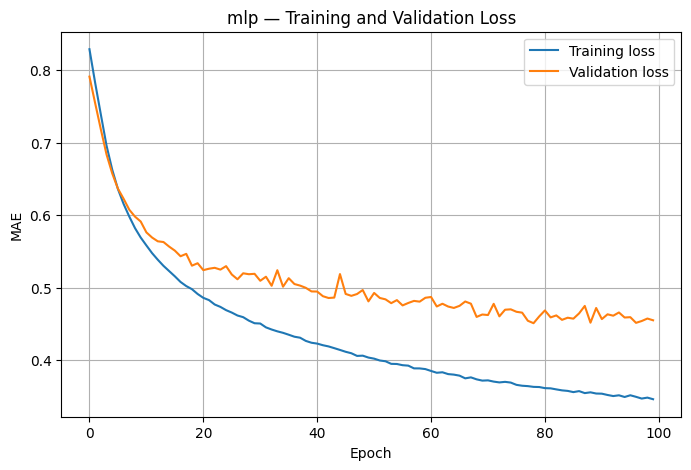

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_mlp.history["loss"], label="Training loss")
plt.plot(history_mlp.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("mlp — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### 1.5 Predictions and reconstruction error

In [16]:
y_pred_scaled_mlp = model_mlp(X_test_scaled_mlp, training=False).numpy()
y_pred_mlp = target_scaler_mlp.inverse_transform(y_pred_scaled_mlp)

errors_mlp = np.linalg.norm(y_pred_mlp - y_test_mlp, axis=1)

mean_error_mlp = np.mean(errors_mlp)
median_error_mlp = np.median(errors_mlp)

x_mae_mlp = np.mean(np.abs(y_pred_mlp[:, 0] - y_test_mlp[:, 0]))
y_mae_mlp = np.mean(np.abs(y_pred_mlp[:, 1] - y_test_mlp[:, 1]))
z_mae_mlp = np.mean(np.abs(y_pred_mlp[:, 2] - y_test_mlp[:, 2]))

print(f"Mean error   : {mean_error_mlp:.3f} mm")
print(f"Median error : {median_error_mlp:.3f} mm")
print(f"X MAE        : {x_mae_mlp:.3f} mm")
print(f"Y MAE        : {y_mae_mlp:.3f} mm")
print(f"Z MAE        : {z_mae_mlp:.3f} mm")

Mean error   : 1.891 mm
Median error : 1.689 mm
X MAE        : 1.004 mm
Y MAE        : 0.945 mm
Z MAE        : 0.898 mm


### 1.6 Visual diagnostics

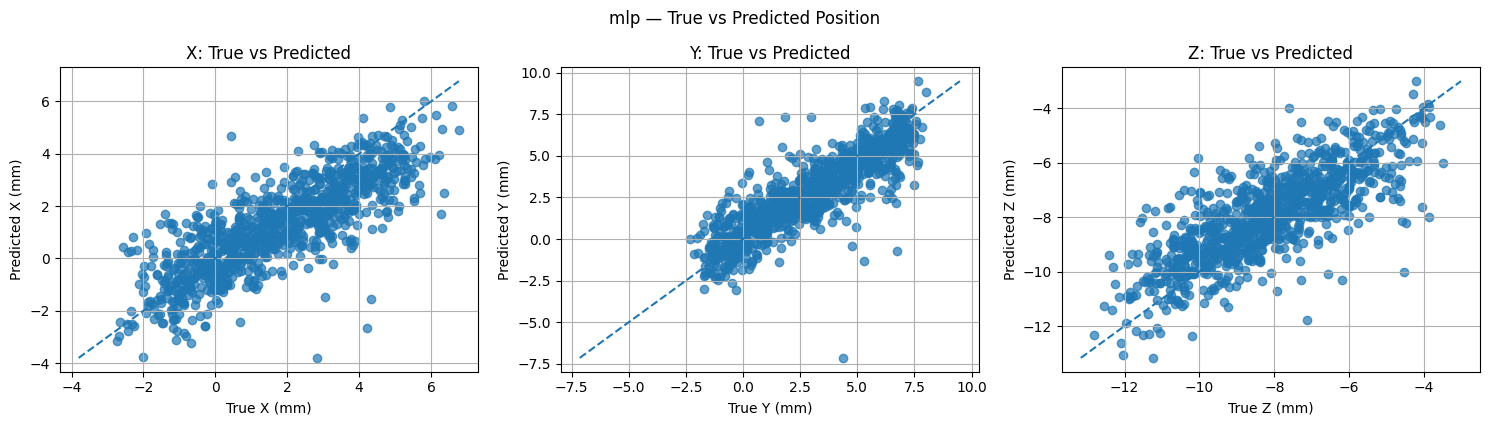

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
coordinates = ["X", "Y", "Z"]

for i, coord in enumerate(coordinates):
    axes[i].scatter(y_test_mlp[:, i], y_pred_mlp[:, i], alpha=0.7)

    minimum = min(y_test_mlp[:, i].min(), y_pred_mlp[:, i].min())
    maximum = max(y_test_mlp[:, i].max(), y_pred_mlp[:, i].max())
    axes[i].plot([minimum, maximum], [minimum, maximum], linestyle="--")

    axes[i].set_xlabel(f"True {coord} (mm)")
    axes[i].set_ylabel(f"Predicted {coord} (mm)")
    axes[i].set_title(f"{coord}: True vs Predicted")
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("mlp — True vs Predicted Position", y=1.05)
plt.show()

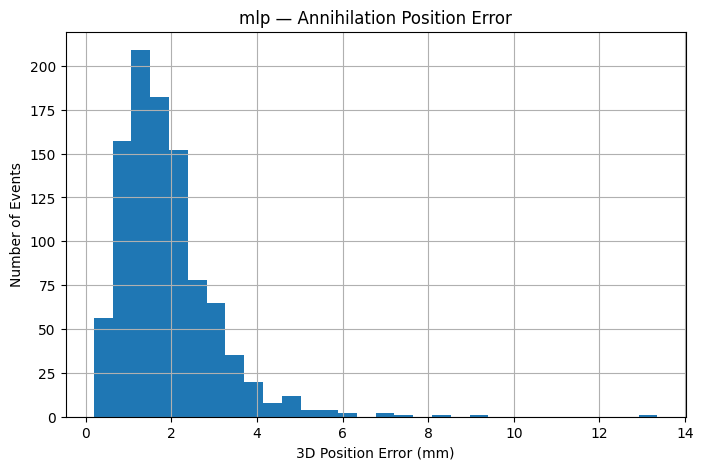

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(errors_mlp, bins=30)
plt.xlabel("3D Position Error (mm)")
plt.ylabel("Number of Events")
plt.title("mlp — Annihilation Position Error")
plt.grid(True)
plt.show()

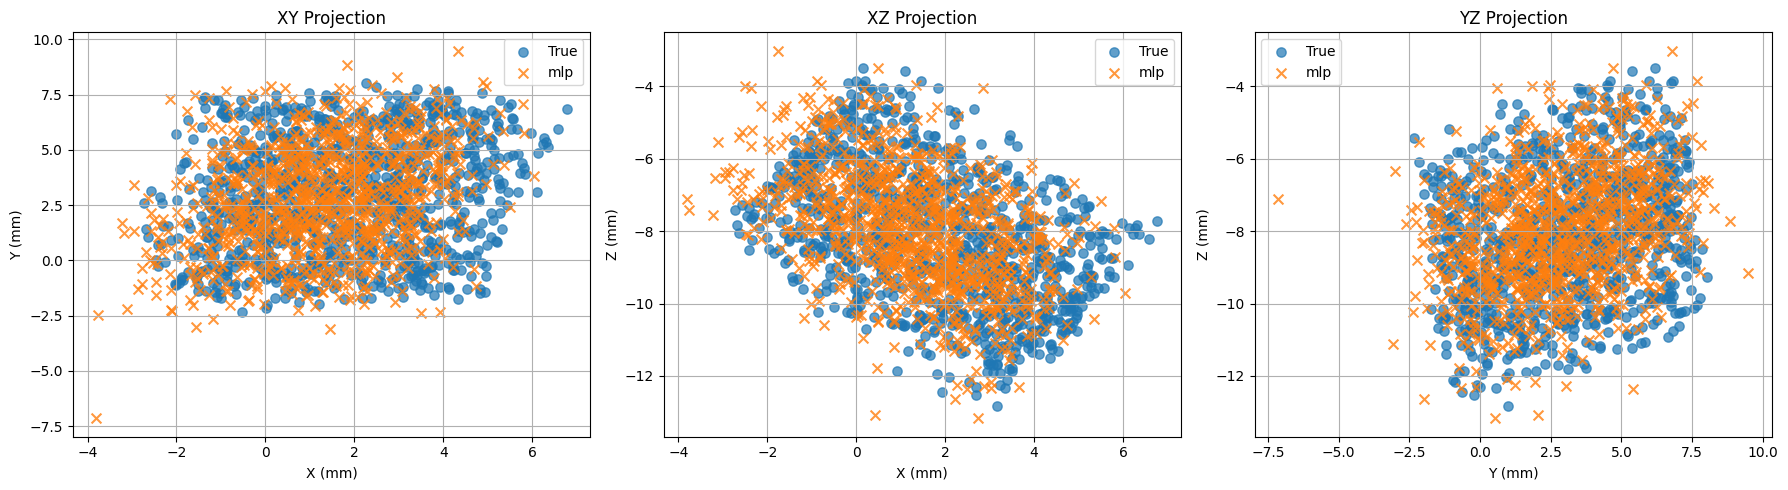

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_mlp[:, i], y_test_mlp[:, j], marker="o", s=45, alpha=0.7, label="True")
    ax.scatter(y_pred_mlp[:, i], y_pred_mlp[:, j], marker="x", s=50, alpha=0.8, label="mlp")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

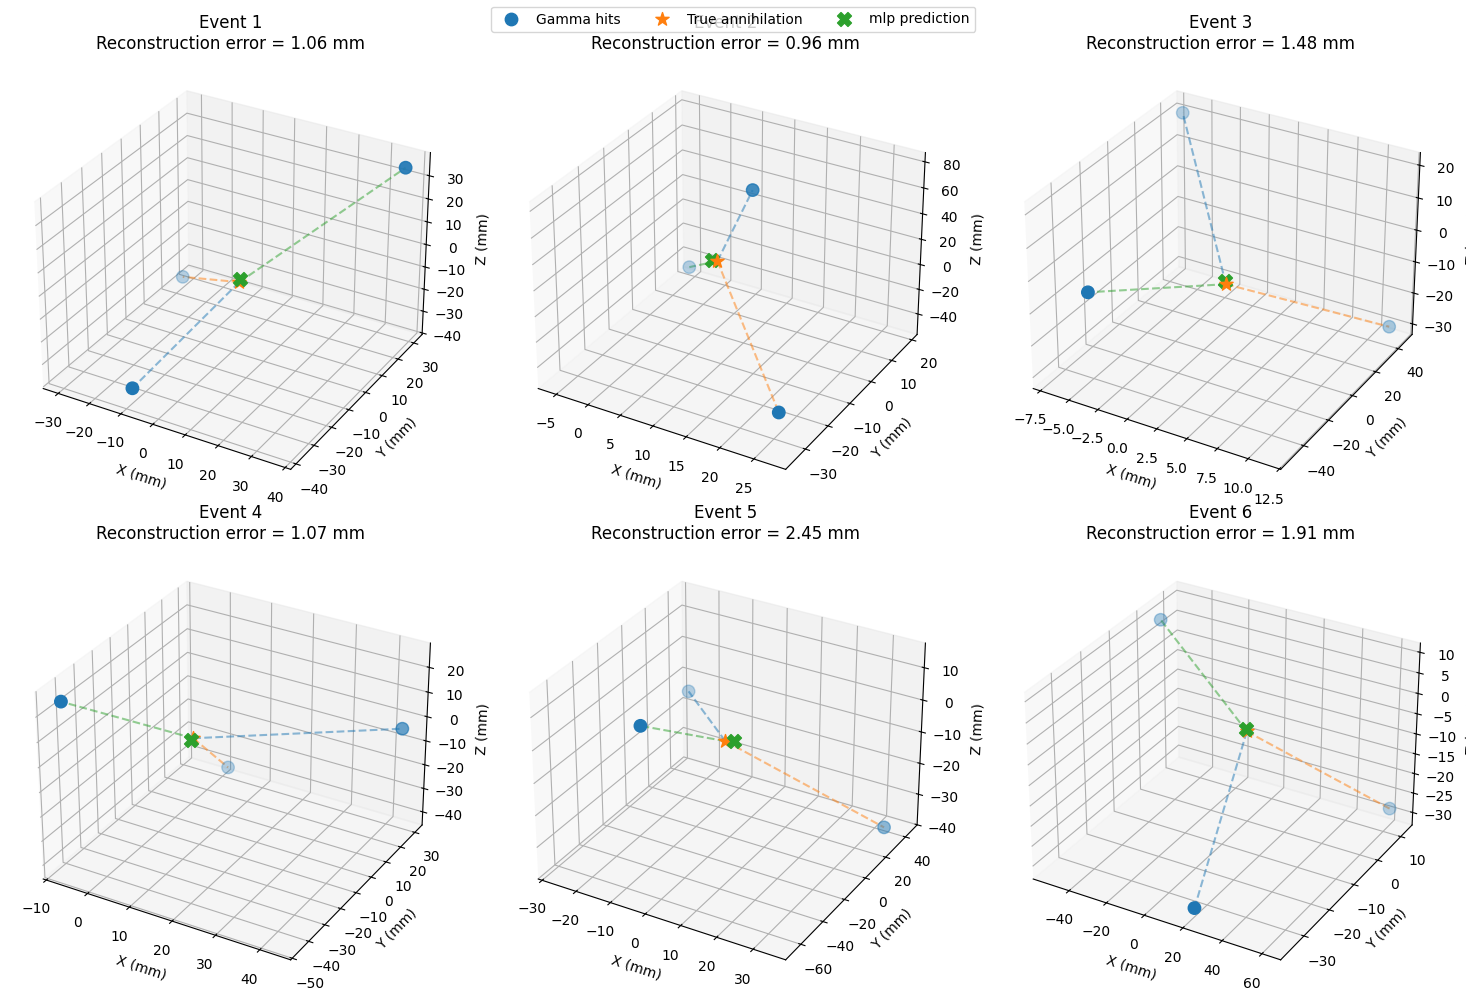

In [20]:
n_events = min(6, len(X_test_mlp))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    hits = np.array([X_test_mlp[i, 0:3], X_test_mlp[i, 4:7], X_test_mlp[i, 8:11]])
    true_pos = y_test_mlp[i]
    pred_pos = y_pred_mlp[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="mlp prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i + 1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

### 1.7 Baseline comparison (naive mean-position predictor)

In [21]:
mean_position_mlp = np.mean(y_train_mlp, axis=0)
print("Mean annihilation position (train):", mean_position_mlp)

mean_predictions_mlp = np.tile(mean_position_mlp, (len(y_test_mlp), 1))
mean_errors_mlp = np.linalg.norm(mean_predictions_mlp - y_test_mlp, axis=1)

print("\nMean-position baseline — mean 3D error  :", np.mean(mean_errors_mlp), "mm")
print("Mean-position baseline — median 3D error:", np.median(mean_errors_mlp), "mm")

improvement_mlp = (np.mean(mean_errors_mlp) - mean_error_mlp) / np.mean(mean_errors_mlp) * 100
print(f"\nmlp mean 3D error   : {mean_error_mlp:.3f} mm")
print(f"Baseline mean 3D error: {np.mean(mean_errors_mlp):.3f} mm")
print(f"Improvement over baseline: {improvement_mlp:.1f}%")

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error  : 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

mlp mean 3D error   : 1.891 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 46.7%


### 1.8 Summary

In [99]:
results_mlp = {
    "model": "mlp",
    "mae_x": x_mae_mlp,
    "mae_y": y_mae_mlp,
    "mae_z": z_mae_mlp,
    "mae_overall": mean_absolute_error(y_test_mlp, y_pred_mlp),
    "mean_3d_error_mm": mean_error_mlp,
    "median_3d_error_mm": median_error_mlp,
    "std_3d_error_mm": np.std(errors_mlp),
    "max_3d_error_mm": np.max(errors_mlp),
    "r2_overall": r2_score(y_test_mlp, y_pred_mlp),
    "improvement_over_mean_baseline_pct": improvement_mlp,
}

---
## 2. `pc_mlp` — plane-constrained MLP

Same style of MLP, extended with three opening-angle features (18 inputs total) and trained with a **custom loss** that adds a penalty for predictions landing off the plane defined by the three detector hits:

`total_loss = mae_loss + lambda_plane * plane_loss`

Setting `lambda_plane = 0` recovers a plain MAE-only MLP — that variant is trained alongside the real plane-constrained model (`lambda_plane = 0.1`) as an internal baseline, so the effect of the plane term can be isolated directly.

### 2.1 Feature engineering (+ opening angles, + event plane)

In [23]:
def build_event_arrays(df_events):
    """Turn the flat hit-level dataframe into per-event feature / target /
    plane arrays, keeping only events with 3 well-separated hits."""

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(["RunID", "EventID"]):
        event = event.sort_values("GammaIndex")

        if len(event) < 3:
            continue
        event = event.iloc[:3]

        hit1, hit2, hit3 = (
            event[["X_mm", "Y_mm", "Z_mm"]].iloc[i].values.astype(float)
            for i in range(3)
        )

        # --- event plane: point + unit normal ---
        v1 = hit2 - hit1
        v2 = hit3 - hit1
        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            # Degenerate / near-collinear triangle: plane is undefined, skip.
            continue

        normal = normal / normal_length
        plane_point = hit1
        plane_list.append(np.concatenate([plane_point, normal]))

        # --- energies ---
        e1, e2, e3 = (float(event.iloc[i]["EnergyDeposit_keV"]) for i in range(3))

        # --- pairwise distances ---
        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        # --- opening angles ---
        def angle_at(vertex, a, b):
            va = a - vertex
            vb = b - vertex
            cos_angle = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-8)
            return np.arccos(np.clip(cos_angle, -1.0, 1.0))

        angle1 = angle_at(hit1, hit2, hit3)
        angle2 = angle_at(hit2, hit1, hit3)
        angle3 = angle_at(hit3, hit1, hit2)

        features_list.append(np.concatenate(
            [hit1, [e1], hit2, [e2], hit3, [e3], [d12, d13, d23], [angle1, angle2, angle3]]
        ))

        target = event[["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]].iloc[0].values.astype(float)
        targets_list.append(target)

    return np.array(features_list), np.array(targets_list), np.array(plane_list)


X_pcmlp, y_pcmlp, plane_data_pcmlp = build_event_arrays(df_subset)

print("X_pcmlp shape:", X_pcmlp.shape)
print("y_pcmlp shape:", y_pcmlp.shape)
print("plane_data_pcmlp shape:", plane_data_pcmlp.shape)

X_pcmlp shape: (15000, 18)
y_pcmlp shape: (15000, 3)
plane_data_pcmlp shape: (15000, 6)


### 2.2 Train / validation / test split, then scale

In [24]:
X_train_pcmlp, X_temp_pcmlp, y_train_pcmlp, y_temp_pcmlp, plane_train_pcmlp, plane_temp_pcmlp = train_test_split(
    X_pcmlp, y_pcmlp, plane_data_pcmlp, test_size=0.20, random_state=RANDOM_STATE
)

X_val_pcmlp, X_test_pcmlp, y_val_pcmlp, y_test_pcmlp, plane_val_pcmlp, plane_test_pcmlp = train_test_split(
    X_temp_pcmlp, y_temp_pcmlp, plane_temp_pcmlp, test_size=0.33, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train_pcmlp)}  Val: {len(X_val_pcmlp)}  Test: {len(X_test_pcmlp)}")

Train: 12000  Val: 2010  Test: 990


In [25]:
input_scaler_pcmlp = StandardScaler()

X_train_scaled_pcmlp = input_scaler_pcmlp.fit_transform(X_train_pcmlp)
X_val_scaled_pcmlp = input_scaler_pcmlp.transform(X_val_pcmlp)
X_test_scaled_pcmlp = input_scaler_pcmlp.transform(X_test_pcmlp)

### 2.3 Plane-constrained model with a custom `train_step`

Two loss terms:

- **`mae_loss`** — standard mean absolute error between predicted and true position.
- **`plane_loss`** — mean squared *signed* distance of the predicted point from the event plane (dot product of `(y_pred - plane_point)` with the plane's unit normal). Since `y_pred` is produced inside the `GradientTape` context, this term is fully differentiable and pulls predictions towards the plane during training.

The loss computation is shared between `train_step` and `test_step` via `_compute_losses`, so training and evaluation can never quietly drift apart.

In [26]:
class PlaneConstrainedMLP(tf.keras.Model):
    """MLP that regresses the 3D annihilation position, optionally penalised
    for predicting a point off the event plane.

    Set `lambda_plane=0.0` to disable the plane term entirely (plain MAE model).
    """

    def __init__(self, lambda_plane=1.0, hidden_units=100, name="plane_mlp"):
        super().__init__(name=name)
        self.lambda_plane = lambda_plane

        self.dense1 = tf.keras.layers.Dense(hidden_units, activation="relu")
        self.dense2 = tf.keras.layers.Dense(hidden_units, activation="relu")
        self.output_layer = tf.keras.layers.Dense(3)

        self.mae_tracker = tf.keras.metrics.Mean(name="mae")
        self.plane_tracker = tf.keras.metrics.Mean(name="plane_loss")
        self.total_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        # Listing these lets Keras auto-reset them at the start of every epoch.
        return [self.total_tracker, self.mae_tracker, self.plane_tracker]

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.output_layer(x)

    def _compute_losses(self, x, y_true, plane_data, training):
        """Shared forward pass + loss computation for train_step/test_step."""

        plane_point = plane_data[:, 0:3]
        plane_normal = plane_data[:, 3:6]
        plane_normal = plane_normal / (
            tf.norm(plane_normal, axis=1, keepdims=True) + 1e-8
        )

        y_pred = self(x, training=training)

        mae_loss = tf.reduce_mean(tf.abs(y_true - y_pred))

        # Signed distance from the predicted point to the event plane.
        displacement = y_pred - plane_point
        distance_from_plane = tf.reduce_sum(displacement * plane_normal, axis=1)
        plane_loss = tf.reduce_mean(tf.square(distance_from_plane))

        total_loss = mae_loss + self.lambda_plane * plane_loss

        return y_pred, mae_loss, plane_loss, total_loss

    def _update_and_report(self, mae_loss, plane_loss, total_loss):
        self.mae_tracker.update_state(mae_loss)
        self.plane_tracker.update_state(plane_loss)
        self.total_tracker.update_state(total_loss)
        return {
            "loss": self.total_tracker.result(),
            "mae": self.mae_tracker.result(),
            "plane_loss": self.plane_tracker.result(),
        }

    def train_step(self, data):
        x, y_true, plane_data = data

        with tf.GradientTape() as tape:
            _, mae_loss, plane_loss, total_loss = self._compute_losses(
                x, y_true, plane_data, training=True
            )

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        return self._update_and_report(mae_loss, plane_loss, total_loss)

    def test_step(self, data):
        x, y_true, plane_data = data
        _, mae_loss, plane_loss, total_loss = self._compute_losses(
            x, y_true, plane_data, training=False
        )
        return self._update_and_report(mae_loss, plane_loss, total_loss)

### 2.4 Build the datasets, and two models to compare



In [27]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
LAMBDA_PLANE = 0.1  # weight of the plane-constraint term for pc_mlp

train_dataset_pcmlp = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled_pcmlp, tf.cast(y_train_pcmlp, tf.float32), tf.cast(plane_train_pcmlp, tf.float32))
).shuffle(len(X_train_scaled_pcmlp)).batch(BATCH_SIZE)

val_dataset_pcmlp = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled_pcmlp, tf.cast(y_val_pcmlp, tf.float32), tf.cast(plane_val_pcmlp, tf.float32))
).batch(BATCH_SIZE)

In [28]:
def make_model(lambda_plane, name):
    model = PlaneConstrainedMLP(lambda_plane=lambda_plane, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        run_eagerly=True,
    )
    return model

pcmlp_baseline = make_model(lambda_plane=0.0, name="pcmlp_baseline")
pc_mlp = make_model(lambda_plane=LAMBDA_PLANE, name="pc_mlp")

### 2.5 Train both models

In [29]:
print("Training pcmlp_baseline (MAE-only) model...")
history_pcmlp_baseline = pcmlp_baseline.fit(
    train_dataset_pcmlp, epochs=EPOCHS, validation_data=val_dataset_pcmlp
)

Training pcmlp_baseline (MAE-only) model...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 2.0459 - mae: 2.0459 - plane_loss: 6.6394 - val_loss: 1.7585 - val_mae: 1.7585 - val_plane_loss: 4.6269
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1.7489 - mae: 1.7489 - plane_loss: 4.1815 - val_loss: 1.7040 - val_mae: 1.7040 - val_plane_loss: 4.1432
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 1.6792 - mae: 1.6792 - plane_loss: 3.6185 - val_loss: 1.6465 - val_mae: 1.6465 - val_plane_loss: 3.6146
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 1.6094 - mae: 1.6094 - plane_loss: 3.1041 - val_loss: 1.5877 - val_mae: 1.5877 - val_plane_loss: 3.2365
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 1.5473 - mae: 1.5473 - plane_loss: 2.7245 - val_loss: 1.5220 - val_mae: 1.5220 - val_plane_loss: 2.8187
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 1.4867 - mae: 1.4867 - plane_loss: 2.4001 - val_loss: 1.4899 - v

In [30]:
print("Training pc_mlp (plane-constrained) model...")
history_pc_mlp = pc_mlp.fit(
    train_dataset_pcmlp, epochs=EPOCHS, validation_data=val_dataset_pcmlp
)

Training pc_mlp (plane-constrained) model...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 2.6106 - mae: 2.0009 - plane_loss: 6.0972 - val_loss: 2.2092 - val_mae: 1.7612 - val_plane_loss: 4.4796
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 2.1342 - mae: 1.7430 - plane_loss: 3.9120 - val_loss: 2.0434 - val_mae: 1.6805 - val_plane_loss: 3.6289
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 1.9714 - mae: 1.6615 - plane_loss: 3.0992 - val_loss: 1.8909 - val_mae: 1.6081 - val_plane_loss: 2.8276
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1.8241 - mae: 1.5810 - plane_loss: 2.4317 - val_loss: 1.7850 - val_mae: 1.5526 - val_plane_loss: 2.3234
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 1.7095 - mae: 1.5098 - plane_loss: 1.9971 - val_loss: 1.6958 - val_mae: 1.5031 - val_plane_loss: 1.9275
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 1.6227 - mae: 1.4541 - plane_loss: 1.6858 - val_loss: 1.6288 - 

### 2.6 Training curves: pcmlp_baseline vs. pc_mlp

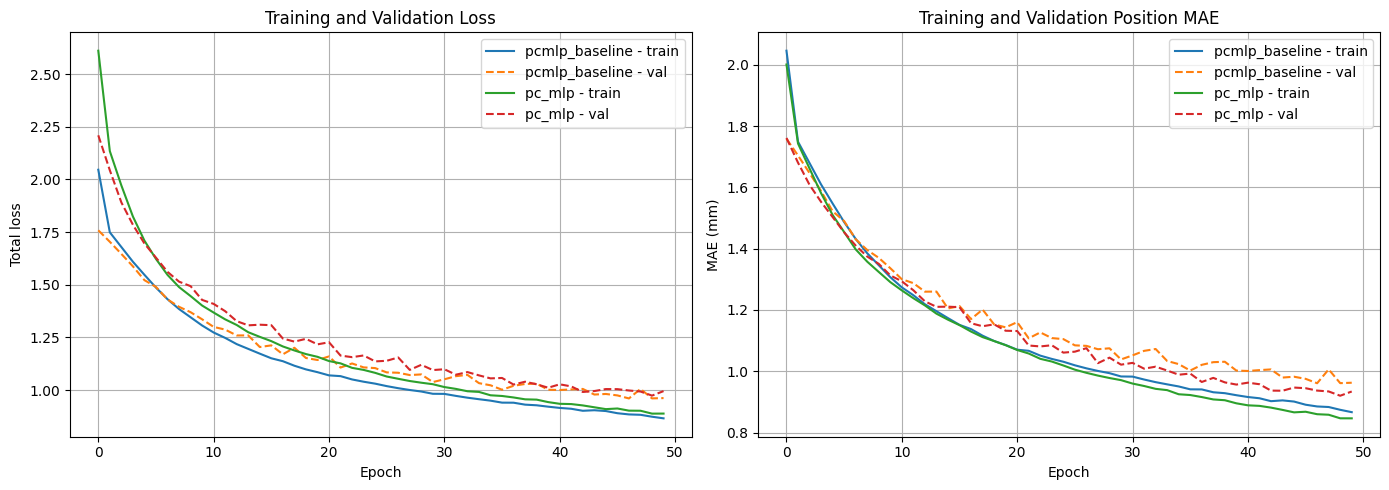

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_pcmlp_baseline.history["loss"], label="pcmlp_baseline - train")
axes[0].plot(history_pcmlp_baseline.history["val_loss"], label="pcmlp_baseline - val", linestyle="--")
axes[0].plot(history_pc_mlp.history["loss"], label="pc_mlp - train")
axes[0].plot(history_pc_mlp.history["val_loss"], label="pc_mlp - val", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_pcmlp_baseline.history["mae"], label="pcmlp_baseline - train")
axes[1].plot(history_pcmlp_baseline.history["val_mae"], label="pcmlp_baseline - val", linestyle="--")
axes[1].plot(history_pc_mlp.history["mae"], label="pc_mlp - train")
axes[1].plot(history_pc_mlp.history["val_mae"], label="pc_mlp - val", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (mm)")
axes[1].set_title("Training and Validation Position MAE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 2.7 Test-set evaluation

Predict with both models on the held-out test set, then compare:
1. Overall 3D reconstruction error (does the plane constraint actually help?)
2. Per-coordinate error
3. How close predictions actually land to their event plane

In [32]:
y_pred_pcmlp_baseline = pcmlp_baseline.predict(X_test_scaled_pcmlp)
y_pred_pc_mlp = pc_mlp.predict(X_test_scaled_pcmlp)

print("y_test_pcmlp shape:        ", y_test_pcmlp.shape)
print("y_pred_pcmlp_baseline shape:", y_pred_pcmlp_baseline.shape)
print("y_pred_pc_mlp shape:        ", y_pred_pc_mlp.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
y_test_pcmlp shape:         (990, 3)
y_pred_pcmlp_baseline shape: (990, 3)
y_pred_pc_mlp shape:         (990, 3)


In [33]:
def summarise_error(name, y_true, y_pred):
    err = np.linalg.norm(y_pred - y_true, axis=1)
    return {
        "model": name,
        "mean_error_mm": np.mean(err),
        "median_error_mm": np.median(err),
        "std_error_mm": np.std(err),
        "max_error_mm": np.max(err),
    }

summary_pcmlp = pd.DataFrame([
    summarise_error("pcmlp_baseline (MAE only)", y_test_pcmlp, y_pred_pcmlp_baseline),
    summarise_error("pc_mlp (plane-constrained)", y_test_pcmlp, y_pred_pc_mlp),
]).set_index("model")

summary_pcmlp

,mean_error_mm,median_error_mm,std_error_mm,max_error_mm
model,,,,
pcmlp_baseline (MAE only),1.933104,1.715289,1.055848,7.245935
pc_mlp (plane-constrained),1.828645,1.610264,1.078514,7.077249


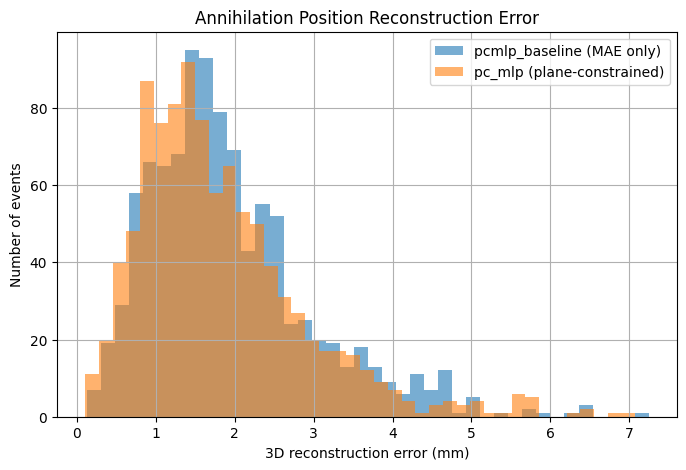

In [34]:
reconstruction_error_pcmlp_baseline = np.linalg.norm(y_pred_pcmlp_baseline - y_test_pcmlp, axis=1)
reconstruction_error_pc_mlp = np.linalg.norm(y_pred_pc_mlp - y_test_pcmlp, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error_pcmlp_baseline, bins=40, alpha=0.6, label="pcmlp_baseline (MAE only)")
plt.hist(reconstruction_error_pc_mlp, bins=40, alpha=0.6, label="pc_mlp (plane-constrained)")
plt.xlabel("3D reconstruction error (mm)")
plt.ylabel("Number of events")
plt.title("Annihilation Position Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

### 2.8 Did the plane constraint actually pull predictions towards the plane?

This checks the thing `plane_loss` was directly optimising: the perpendicular distance from each *predicted* point to its own event's plane, for both models. If the constraint is working, `pc_mlp` should show noticeably smaller plane-distances than `pcmlp_baseline`.

In [35]:
def distance_to_plane(y_pred, plane):
    plane_point = plane[:, 0:3]
    plane_normal = plane[:, 3:6]
    plane_normal = plane_normal / (
        np.linalg.norm(plane_normal, axis=1, keepdims=True) + 1e-8
    )
    displacement = y_pred - plane_point
    return np.abs(np.sum(displacement * plane_normal, axis=1))


plane_dist_pcmlp_baseline = distance_to_plane(y_pred_pcmlp_baseline, plane_test_pcmlp)
plane_dist_pc_mlp = distance_to_plane(y_pred_pc_mlp, plane_test_pcmlp)

print("pcmlp_baseline - mean/median distance to plane (mm):",
      np.mean(plane_dist_pcmlp_baseline), "/", np.median(plane_dist_pcmlp_baseline))
print("pc_mlp - mean/median distance to plane (mm):",
      np.mean(plane_dist_pc_mlp), "/", np.median(plane_dist_pc_mlp))

pcmlp_baseline - mean/median distance to plane (mm): 0.6888922658429073 / 0.5671721712949447
pc_mlp - mean/median distance to plane (mm): 0.6029378182520982 / 0.5033657550296962


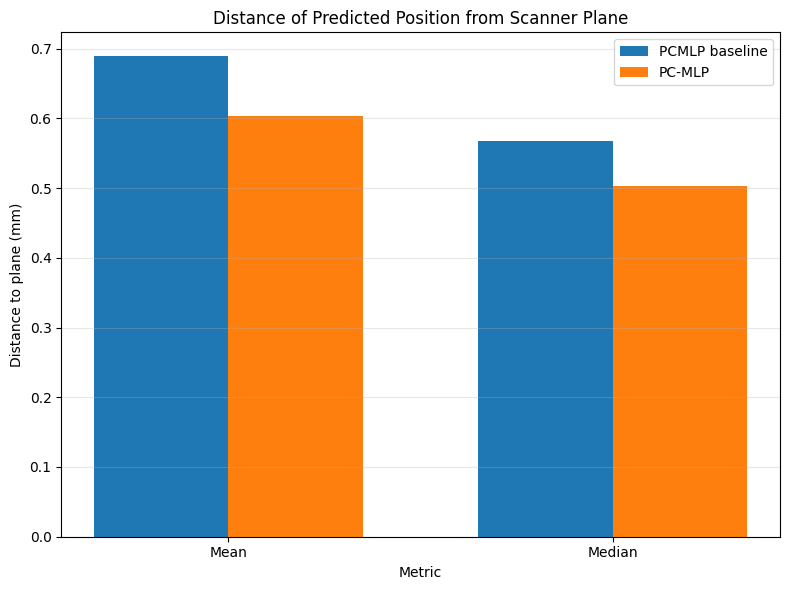

In [36]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Mean", "Median"]

pcmlp_baseline = [np.mean(plane_dist_pcmlp_baseline), np.median(plane_dist_pcmlp_baseline)

]

pc_mlp = [np.mean(plane_dist_pc_mlp), np.median(plane_dist_pc_mlp)

]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 6))

plt.bar(
    x - width/2,
    pcmlp_baseline,
    width,
    label="PCMLP baseline"
)

plt.bar(
    x + width/2,
    pc_mlp,
    width,
    label="PC-MLP"
)

plt.xticks(x, metrics)
plt.ylabel("Distance to plane (mm)")
plt.xlabel("Metric")
plt.title("Distance of Predicted Position from Scanner Plane")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 2.9 Detailed diagnostics for `pc_mlp`

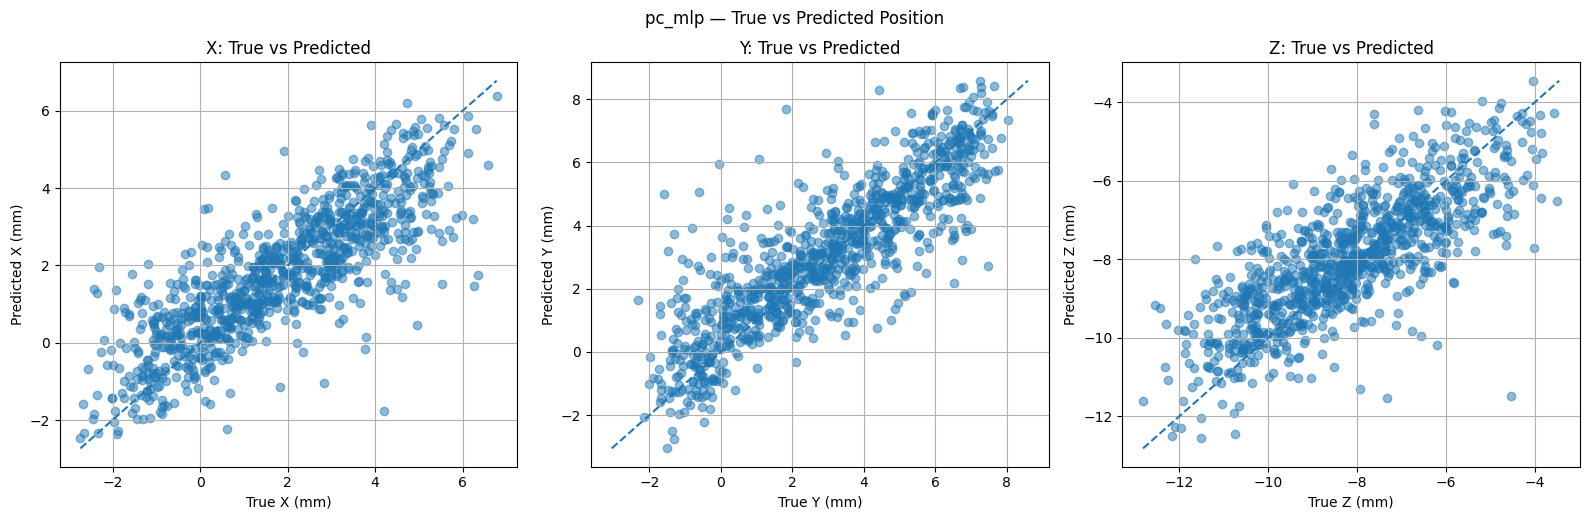

X MAE: 0.8675290885513103
Y MAE: 0.9602955877583361
Z MAE: 0.902584370458969


In [37]:
residuals_pcmlp = y_pred_pc_mlp - y_test_pcmlp

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
coordinates = ["X", "Y", "Z"]

for i, coord in enumerate(coordinates):
    axes[i].scatter(y_test_pcmlp[:, i], y_pred_pc_mlp[:, i], alpha=0.5)

    min_val = min(y_test_pcmlp[:, i].min(), y_pred_pc_mlp[:, i].min())
    max_val = max(y_test_pcmlp[:, i].max(), y_pred_pc_mlp[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle="--")

    axes[i].set_xlabel(f"True {coord} (mm)")
    axes[i].set_ylabel(f"Predicted {coord} (mm)")
    axes[i].set_title(f"{coord}: True vs Predicted")
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("pc_mlp — True vs Predicted Position", y=1.03)
plt.show()

print("X MAE:", np.mean(np.abs(residuals_pcmlp[:, 0])))
print("Y MAE:", np.mean(np.abs(residuals_pcmlp[:, 1])))
print("Z MAE:", np.mean(np.abs(residuals_pcmlp[:, 2])))

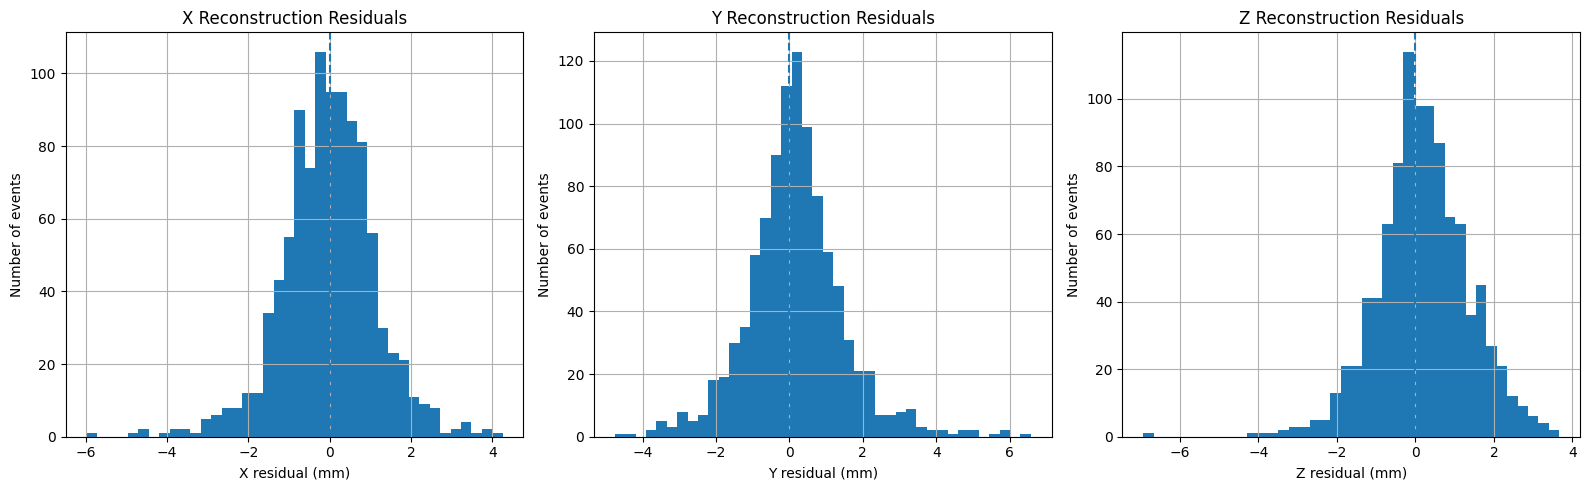

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, coord in enumerate(coordinates):
    axes[i].hist(residuals_pcmlp[:, i], bins=40)
    axes[i].axvline(0, linestyle="--")
    axes[i].set_xlabel(f"{coord} residual (mm)")
    axes[i].set_ylabel("Number of events")
    axes[i].set_title(f"{coord} Reconstruction Residuals")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

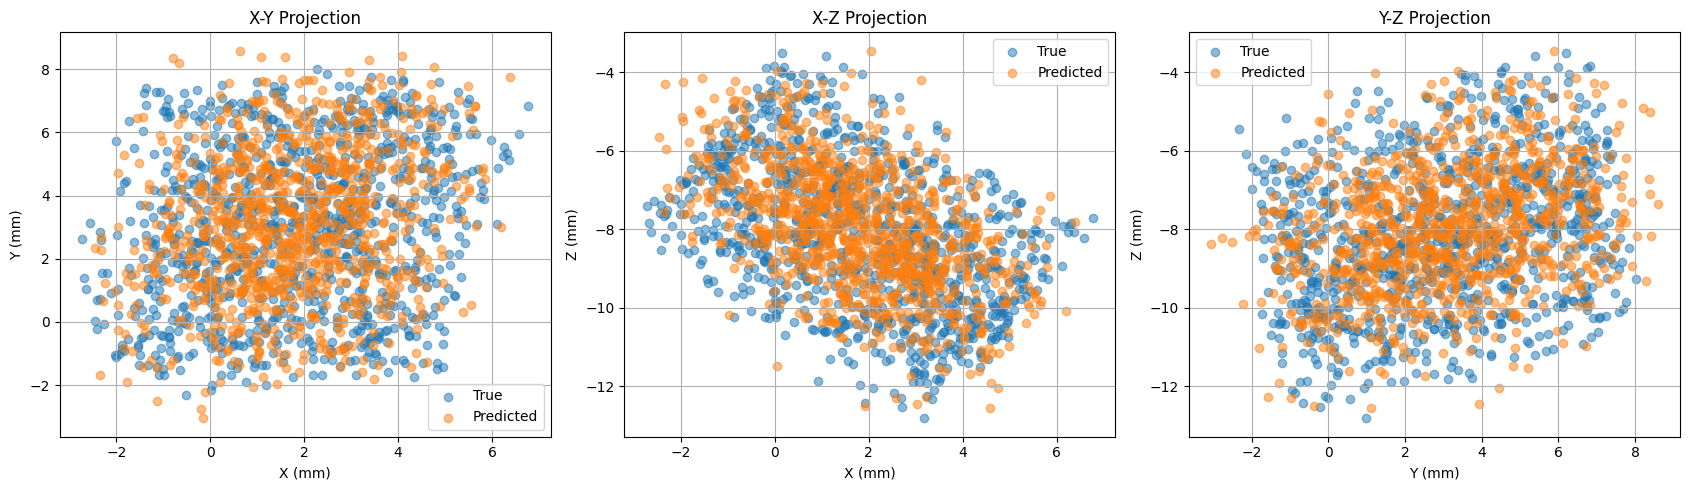

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_pcmlp[:, i], y_test_pcmlp[:, j], alpha=0.5, label="True")
    ax.scatter(y_pred_pc_mlp[:, i], y_pred_pc_mlp[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

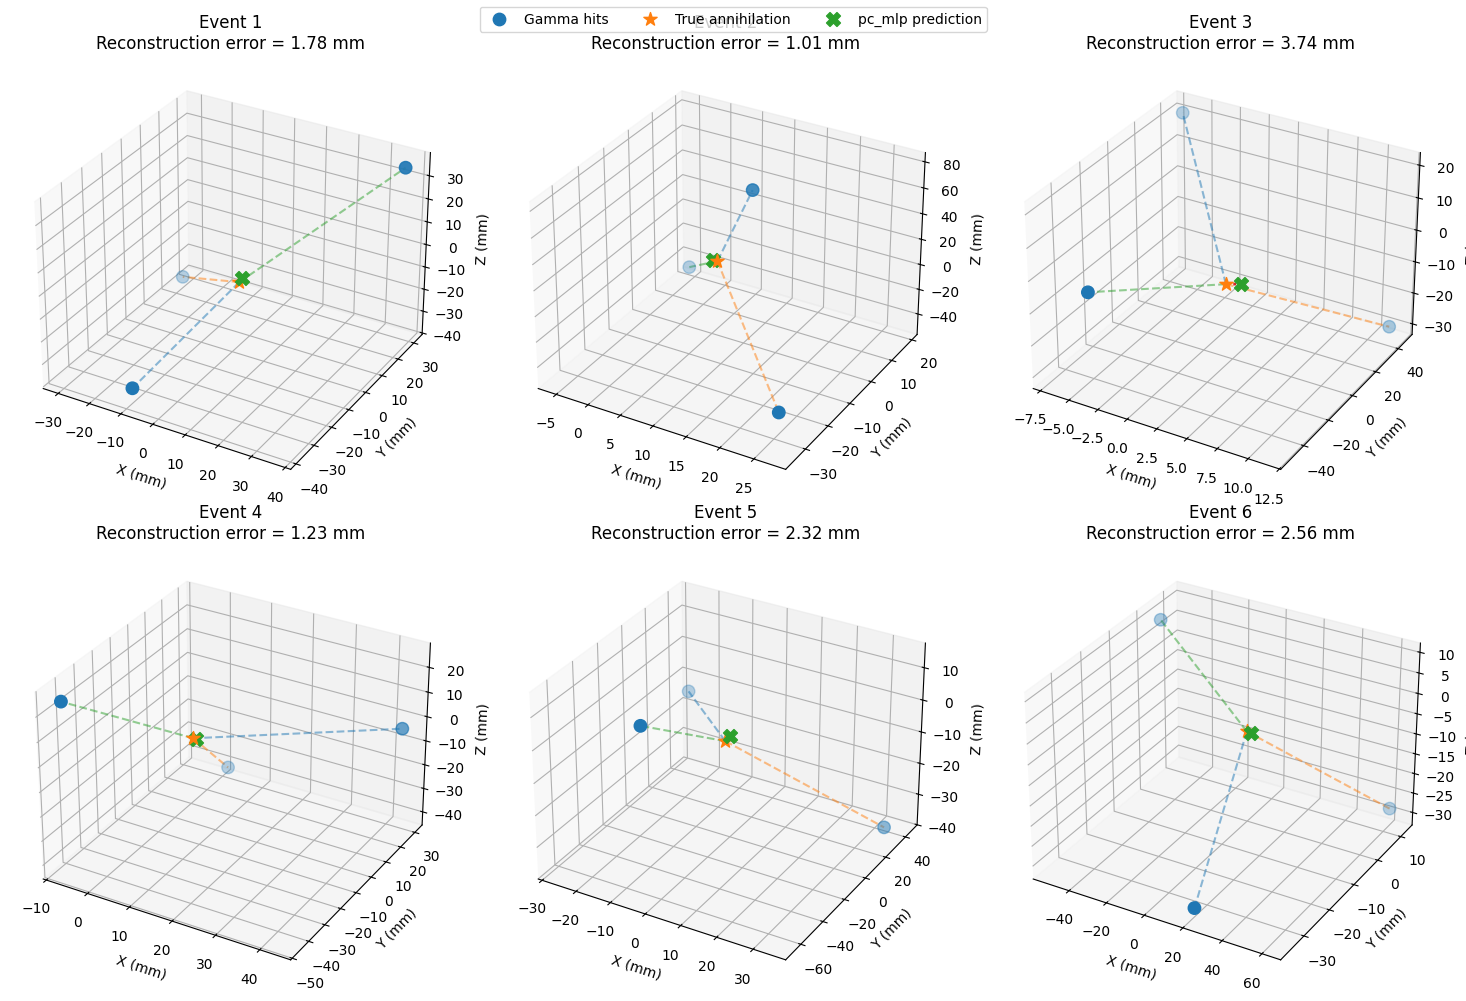

In [40]:
n_events = min(6, len(X_test_pcmlp))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    hits = np.array([X_test_pcmlp[i, 0:3], X_test_pcmlp[i, 4:7], X_test_pcmlp[i, 8:11]])
    true_pos = y_test_pcmlp[i]
    pred_pos = y_pred_pc_mlp[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="pc_mlp prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i + 1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

### 2.10 Baseline comparison (naive mean-position predictor)

In [41]:
mean_position_pcmlp = np.mean(y_train_pcmlp, axis=0)
print("Mean annihilation position (train):", mean_position_pcmlp)

mean_predictions_pcmlp = np.tile(mean_position_pcmlp, (len(y_test_pcmlp), 1))
mean_errors_pcmlp = np.linalg.norm(mean_predictions_pcmlp - y_test_pcmlp, axis=1)

print("\nMean-position baseline — mean 3D error  :", np.mean(mean_errors_pcmlp), "mm")
print("Mean-position baseline — median 3D error:", np.median(mean_errors_pcmlp), "mm")

improvement_pcmlp = (
    (np.mean(mean_errors_pcmlp) - np.mean(reconstruction_error_pc_mlp))
    / np.mean(mean_errors_pcmlp) * 100
)
print(f"\npc_mlp mean 3D error    : {np.mean(reconstruction_error_pc_mlp):.3f} mm")
print(f"Baseline mean 3D error : {np.mean(mean_errors_pcmlp):.3f} mm")
print(f"Improvement over baseline: {improvement_pcmlp:.1f}%")

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error  : 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

pc_mlp mean 3D error    : 1.829 mm
Baseline mean 3D error : 3.548 mm
Improvement over baseline: 48.5%


### 2.11 Summary

In [103]:
results_pcmlp = {
    "model": "pc_mlp",
    "mae_x": np.mean(np.abs(residuals_pcmlp[:, 0])),
    "mae_y": np.mean(np.abs(residuals_pcmlp[:, 1])),
    "mae_z": np.mean(np.abs(residuals_pcmlp[:, 2])),
    "mae_overall": mean_absolute_error(y_test_pcmlp, y_pred_pc_mlp),
    "mean_3d_error_mm": np.mean(reconstruction_error_pc_mlp),
    "median_3d_error_mm": np.median(reconstruction_error_pc_mlp),
    "std_3d_error_mm": np.std(reconstruction_error_pc_mlp),
    "max_3d_error_mm": np.max(reconstruction_error_pc_mlp),
    "r2_overall": r2_score(y_test_pcmlp, y_pred_pc_mlp),
    "mean_plane_distance_mm": np.mean(plane_dist_pc_mlp),
    "improvement_over_mean_baseline_pct": improvement_pcmlp,
}

---
## 3. `plane_2d` — hard constraint via u,v conversion (geometric opening angles)

Same 18 features as `pc_mlp` (including the geometric triangle-vertex opening angles), but instead of penalising deviation from the plane in the loss, the target is re-parameterised into two in-plane coordinates `(u, v)` via an orthonormal basis derived from the three hits — so every prediction lies exactly on the plane by construction. Section 4 below repeats this exact hard-constraint architecture but swaps in the **physically correct**, energy-derived opening angle instead of the geometric one used here.

### 3.1 Feature engineering

In [43]:
def build_event_arrays_2d(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):

        event = event.sort_values("GammaIndex")

        if len(event) < 3:
            continue

        event = event.iloc[:3]

        hit1 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[0].values.astype(float)

        hit2 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[1].values.astype(float)

        hit3 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[2].values.astype(float)

        v1 = hit2 - hit1
        v2 = hit3 - hit1

        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length

        basis_u = v1 / (
            np.linalg.norm(v1) + 1e-8
        )

        basis_v = np.cross(normal, basis_u)

        basis_v = basis_v / (
            np.linalg.norm(basis_v) + 1e-8
        )

        plane_data = np.concatenate([
            hit1,
            normal,
            basis_u,
            basis_v
        ])

        plane_list.append(plane_data)

        energy1 = float(
            event.iloc[0]["EnergyDeposit_keV"]
        )

        energy2 = float(
            event.iloc[1]["EnergyDeposit_keV"]
        )

        energy3 = float(
            event.iloc[2]["EnergyDeposit_keV"]
        )

        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        def angle_at(vertex, a, b):

            va = a - vertex
            vb = b - vertex

            cos_angle = np.dot(va, vb) / (
                np.linalg.norm(va)
                * np.linalg.norm(vb)
                + 1e-8
            )

            return np.arccos(
                np.clip(cos_angle, -1.0, 1.0)
            )

        angle1 = angle_at(hit1, hit2, hit3)
        angle2 = angle_at(hit2, hit1, hit3)
        angle3 = angle_at(hit3, hit1, hit2)

        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])

        features_list.append(features)

        target = event[
            [
                "AnnihilX_mm",
                "AnnihilY_mm",
                "AnnihilZ_mm"
            ]
        ].iloc[0].values.astype(float)

        targets_list.append(target)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )


X_plane2d, y_plane2d, plane_data_plane2d = build_event_arrays_2d(
    df_subset
)

print("X_plane2d shape:", X_plane2d.shape)
print("y_plane2d shape:", y_plane2d.shape)
print("plane_data_plane2d shape:", plane_data_plane2d.shape)

X_plane2d shape: (15000, 18)
y_plane2d shape: (15000, 3)
plane_data_plane2d shape: (15000, 12)


### 3.2 train/val/test split

In [44]:
X_train_plane2d, X_temp_plane2d, \
y_train_plane2d, y_temp_plane2d, \
plane_train_plane2d, plane_temp_plane2d = train_test_split(
    X_plane2d,
    y_plane2d,
    plane_data_plane2d,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane2d, X_test_plane2d, \
y_val_plane2d, y_test_plane2d, \
plane_val_plane2d, plane_test_plane2d = train_test_split(
    X_temp_plane2d,
    y_temp_plane2d,
    plane_temp_plane2d,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane2d.shape)
print("Validation:", X_val_plane2d.shape)
print("Test:", X_test_plane2d.shape)

Training: (12000, 18)
Validation: (2010, 18)
Test: (990, 18)


### 3.3 scaling

In [45]:
input_scaler_plane2d = StandardScaler()

X_train_scaled_plane2d = input_scaler_plane2d.fit_transform(
    X_train_plane2d
)

X_val_scaled_plane2d = input_scaler_plane2d.transform(
    X_val_plane2d
)

X_test_scaled_plane2d = input_scaler_plane2d.transform(
    X_test_plane2d
)

### 3.4 converting xyz targets into u,v

In [46]:
def xyz_to_uv_plane2d(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])


y_train_uv_plane2d = xyz_to_uv_plane2d(
    y_train_plane2d,
    plane_train_plane2d
)

y_val_uv_plane2d = xyz_to_uv_plane2d(
    y_val_plane2d,
    plane_val_plane2d
)

y_test_uv_plane2d = xyz_to_uv_plane2d(
    y_test_plane2d,
    plane_test_plane2d
)

print("Training UV:", y_train_uv_plane2d.shape)
print("Validation UV:", y_val_uv_plane2d.shape)
print("Test UV:", y_test_uv_plane2d.shape)

Training UV: (12000, 2)
Validation UV: (2010, 2)
Test UV: (990, 2)


### 3.5 building the MLP

In [47]:
class Plane2DMLP(tf.keras.Model):

    def __init__(self, hidden_units=100):
        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.output_layer = tf.keras.layers.Dense(2)

    def call(self, x, training=False):

        x = self.dense1(x)
        x = self.dense2(x)

        return self.output_layer(x)

### 3.6 compile

In [48]:
model_plane2d = Plane2DMLP(
    hidden_units=100
)

model_plane2d.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mae",
    metrics=["mae"]
)

### 3.7 train

In [49]:
history_plane2d = model_plane2d.fit(
    X_train_scaled_plane2d,
    y_train_uv_plane2d,
    validation_data=(
        X_val_scaled_plane2d,
        y_val_uv_plane2d
    ),
    epochs=100,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 10.2321 - mae: 10.2321 - val_loss: 3.8092 - val_mae: 3.8092
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0857 - mae: 3.0857 - val_loss: 2.6483 - val_mae: 2.6483
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.3895 - mae: 2.3895 - val_loss: 2.2279 - val_mae: 2.2279
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0859 - mae: 2.0859 - val_loss: 2.0056 - val_mae: 2.0056
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9051 - mae: 1.9051 - val_loss: 1.8570 - val_mae: 1.8570
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7673 - mae: 1.7673 - val_loss: 1.7063 - val_mae: 1.7063
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.6655 - mae: 1.6655 - val_loss: 1.6414 - val_mae: 1.6414
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5724 - mae: 1.5724 - val_loss: 1.5558 - val_mae: 1.5558
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5m

### 3.8 convert predictions back to x,y,z

In [50]:
def uv_to_xyz_plane2d(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

### 3.9 prediction shape

In [51]:
uv_pred_plane2d = model_plane2d.predict(
    X_test_scaled_plane2d
)

xyz_pred_plane2d = uv_to_xyz_plane2d(
    uv_pred_plane2d,
    plane_test_plane2d
)

print("XYZ prediction shape:", xyz_pred_plane2d.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
XYZ prediction shape: (990, 3)


### 3.10.1 loss curves

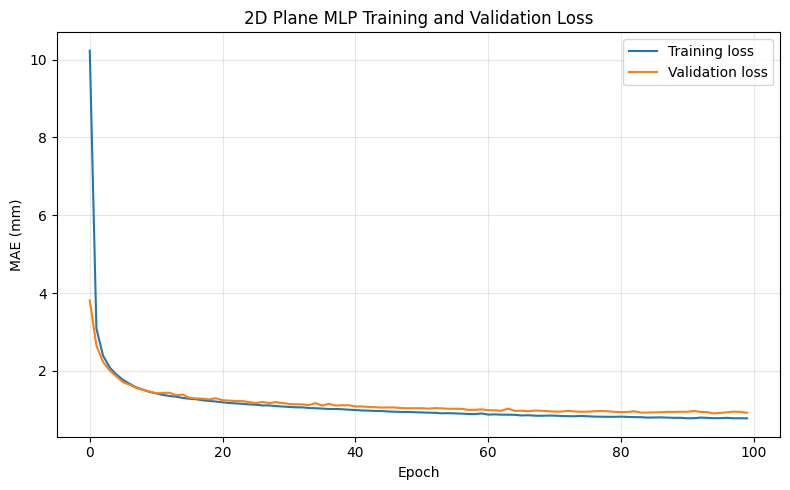

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_plane2d.history["loss"],
    label="Training loss"
)

plt.plot(
    history_plane2d.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("2D Plane MLP Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.10.2 X,Y,Z MAE

In [53]:
errors_plane2d = (
    xyz_pred_plane2d - y_test_plane2d
)

absolute_errors_plane2d = np.abs(
    errors_plane2d
)

x_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 0]
)

y_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 1]
)

z_mae_plane2d = np.mean(
    absolute_errors_plane2d[:, 2]
)

print("X MAE:", x_mae_plane2d, "mm")
print("Y MAE:", y_mae_plane2d, "mm")
print("Z MAE:", z_mae_plane2d, "mm")

X MAE: 0.686412972957183 mm
Y MAE: 0.6734196155186788 mm
Z MAE: 0.6956690613683363 mm


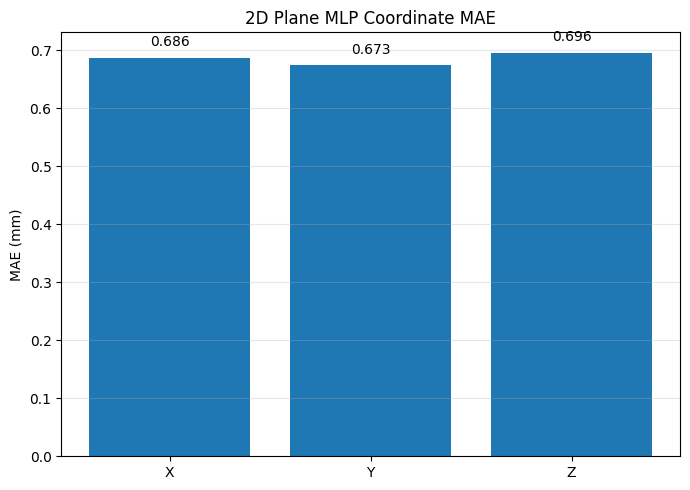

In [54]:
plt.figure(figsize=(7, 5))

maes = [
    x_mae_plane2d,
    y_mae_plane2d,
    z_mae_plane2d
]

plt.bar(
    ["X", "Y", "Z"],
    maes
)

plt.ylabel("MAE (mm)")
plt.title("2D Plane MLP Coordinate MAE")

for i, value in enumerate(maes):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 3.10.3 3D recosntuction error

In [55]:
error_3d_plane2d = np.linalg.norm(
    errors_plane2d,
    axis=1
)

mean_error_plane2d = np.mean(
    error_3d_plane2d
)

median_error_plane2d = np.median(
    error_3d_plane2d
)

max_error_plane2d = np.max(
    error_3d_plane2d
)

std_error_plane2d = np.std(
    error_3d_plane2d
)

print("Mean error   :", f"{mean_error_plane2d:.3f}", "mm")
print("Median error :", f"{median_error_plane2d:.3f}", "mm")
print("Std error    :", f"{std_error_plane2d:.3f}", "mm")
print("Maximum error:", f"{max_error_plane2d:.3f}", "mm")

Mean error   : 1.370 mm
Median error : 1.094 mm
Std error    : 1.093 mm
Maximum error: 10.116 mm


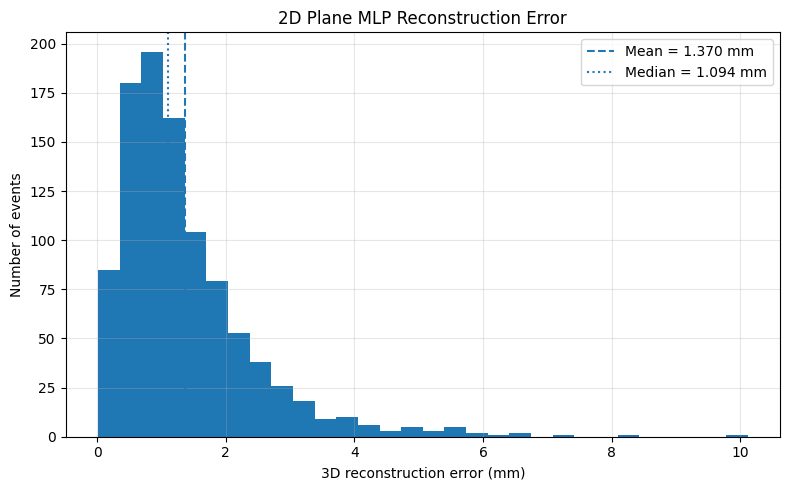

In [56]:
plt.figure(figsize=(8, 5))

plt.hist(
    error_3d_plane2d,
    bins=30
)

plt.axvline(
    mean_error_plane2d,
    linestyle="--",
    label=f"Mean = {mean_error_plane2d:.3f} mm"
)

plt.axvline(
    median_error_plane2d,
    linestyle=":",
    label=f"Median = {median_error_plane2d:.3f} mm"
)

plt.xlabel("3D reconstruction error (mm)")
plt.ylabel("Number of events")
plt.title("2D Plane MLP Reconstruction Error")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.10.4 true vs predicted

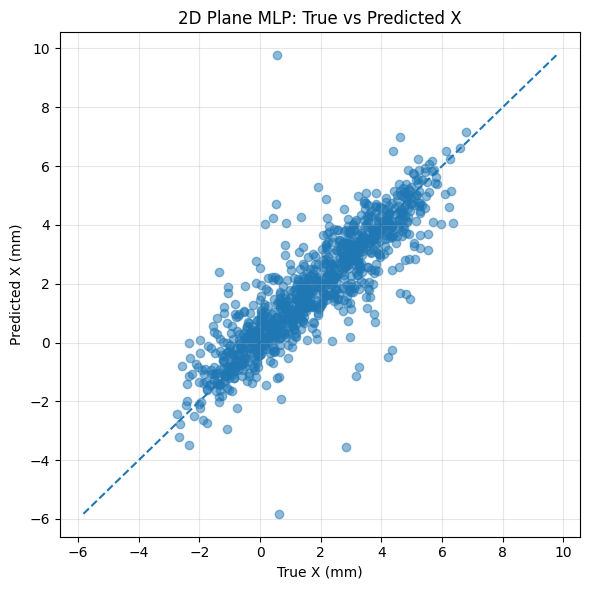

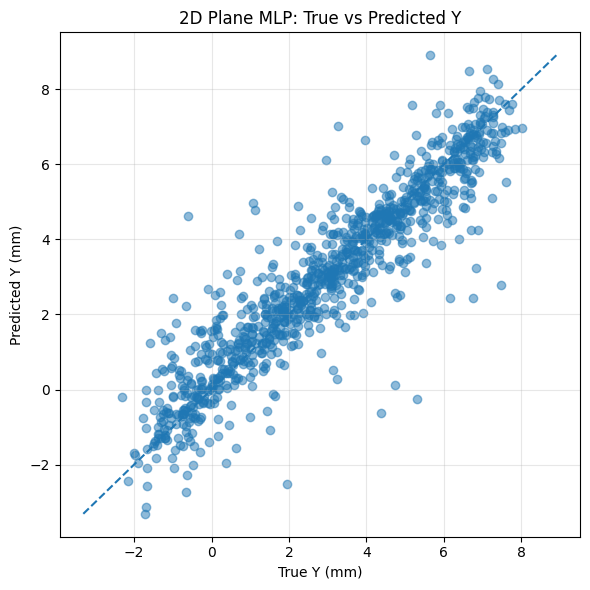

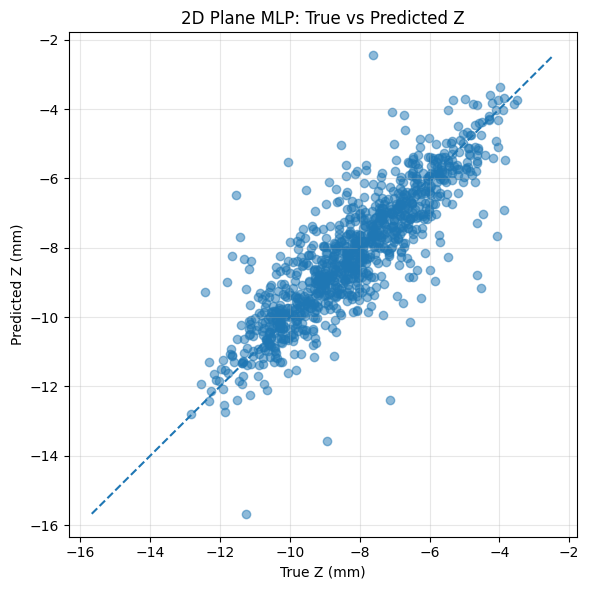

In [57]:
figures = [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]

for coordinate, index in figures:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_plane2d[:, index],
        xyz_pred_plane2d[:, index],
        alpha=0.5
    )

    minimum = min(
        y_test_plane2d[:, index].min(),
        xyz_pred_plane2d[:, index].min()
    )

    maximum = max(
        y_test_plane2d[:, index].max(),
        xyz_pred_plane2d[:, index].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(
        f"2D Plane MLP: True vs Predicted {coordinate}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3.10.5 3d reocnstucted positions

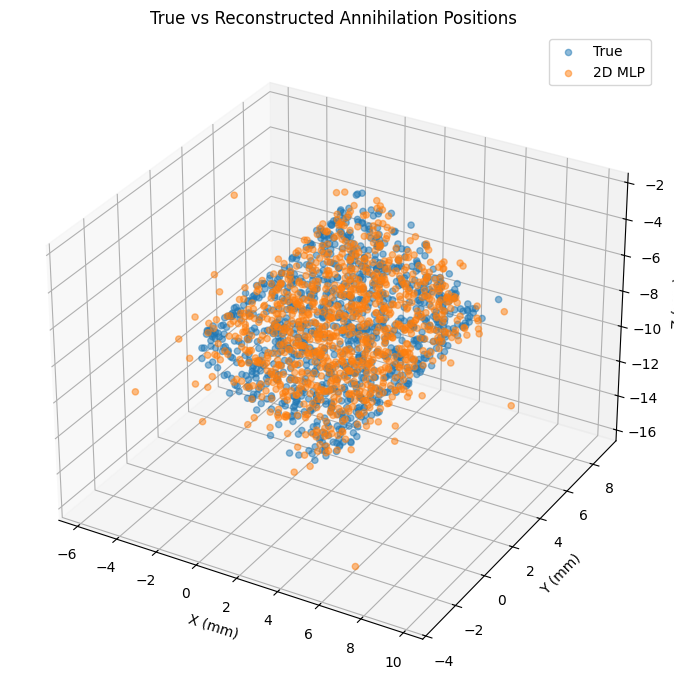

In [58]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    y_test_plane2d[:, 0],
    y_test_plane2d[:, 1],
    y_test_plane2d[:, 2],
    alpha=0.5,
    label="True"
)

ax.scatter(
    xyz_pred_plane2d[:, 0],
    xyz_pred_plane2d[:, 1],
    xyz_pred_plane2d[:, 2],
    alpha=0.5,
    label="2D MLP"
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

ax.set_title(
    "True vs Reconstructed Annihilation Positions"
)

ax.legend()

plt.tight_layout()
plt.show()

### 3.10.6 2d projections

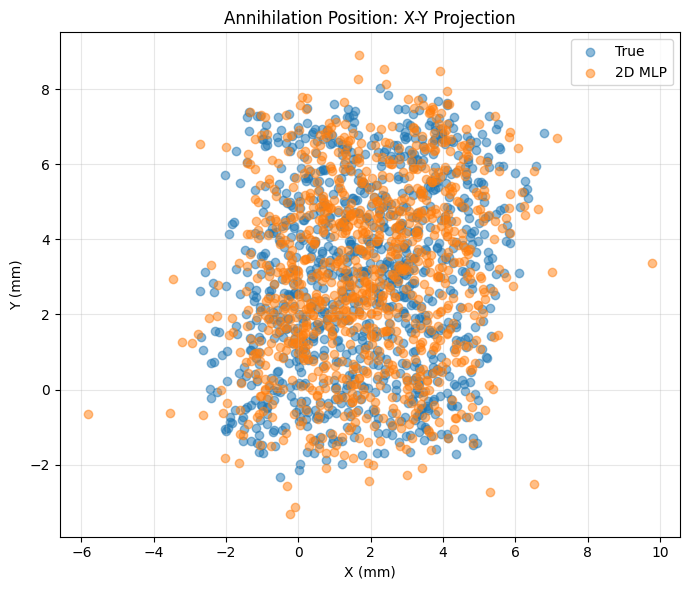

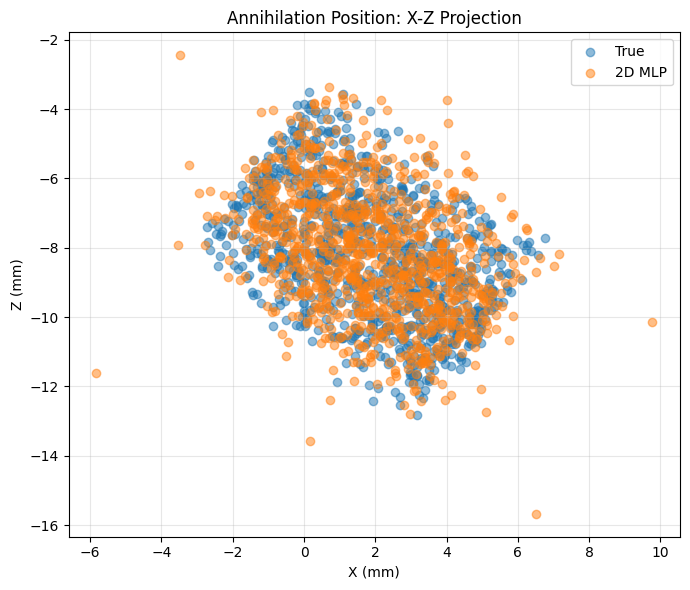

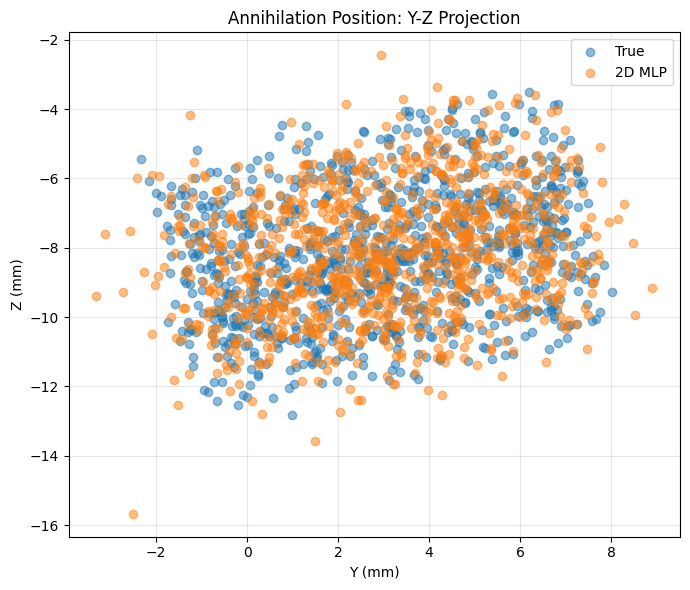

In [59]:
projections = [
    (0, 1, "X", "Y"),
    (0, 2, "X", "Z"),
    (1, 2, "Y", "Z")
]

for i, j, xlabel, ylabel in projections:

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_test_plane2d[:, i],
        y_test_plane2d[:, j],
        alpha=0.5,
        label="True"
    )

    plt.scatter(
        xyz_pred_plane2d[:, i],
        xyz_pred_plane2d[:, j],
        alpha=0.5,
        label="2D MLP"
    )

    plt.xlabel(f"{xlabel} (mm)")
    plt.ylabel(f"{ylabel} (mm)")

    plt.title(
        f"Annihilation Position: {xlabel}-{ylabel} Projection"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3.10.7 residuals

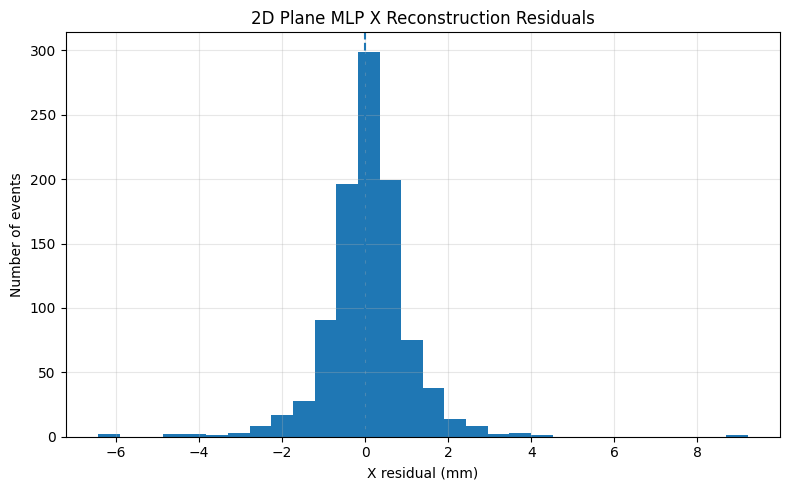

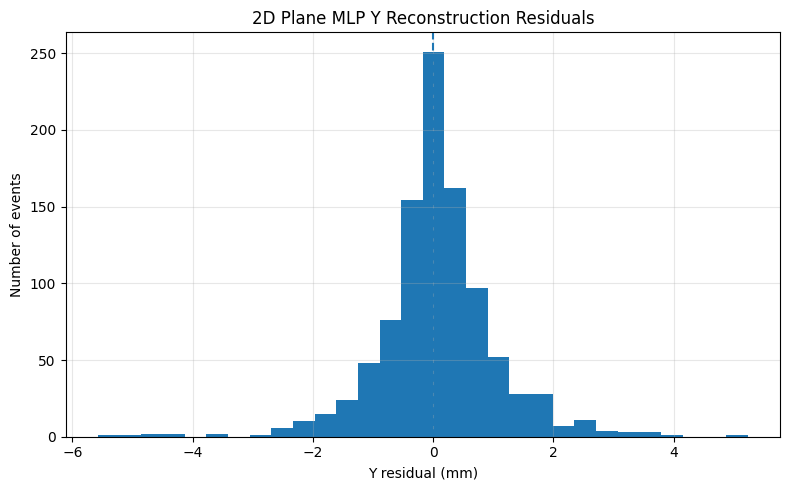

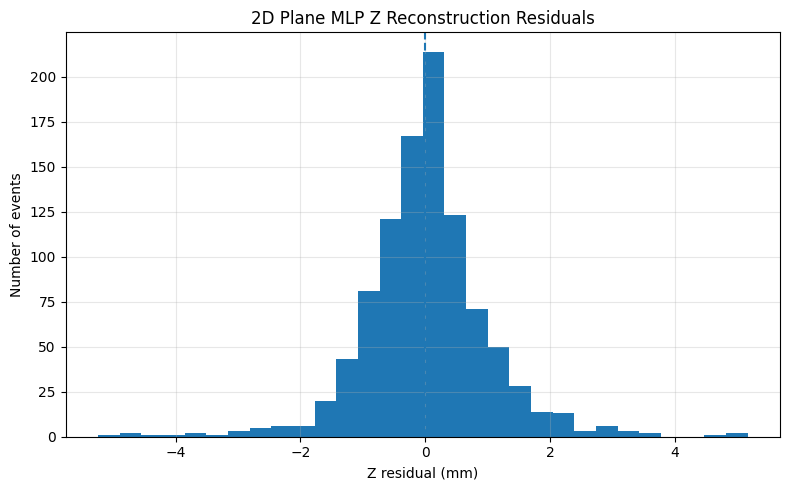

In [60]:
for coordinate, index in [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        errors_plane2d[:, index],
        bins=30
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(f"{coordinate} residual (mm)")
    plt.ylabel("Number of events")
    plt.title(
        f"2D Plane MLP {coordinate} Reconstruction Residuals"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3.10.8 summary

In [61]:
print("2D PLANE MLP PERFORMANCE")

print(f"Mean 3D error   : {mean_error_plane2d:.3f} mm")
print(f"Median 3D error : {median_error_plane2d:.3f} mm")
print(f"Std 3D error    : {std_error_plane2d:.3f} mm")
print(f"Maximum error   : {max_error_plane2d:.3f} mm")

print()

print(f"X MAE           : {x_mae_plane2d:.3f} mm")
print(f"Y MAE           : {y_mae_plane2d:.3f} mm")
print(f"Z MAE           : {z_mae_plane2d:.3f} mm")

print()


print("PLANE CONSTRAINT")

plane_points = plane_test_plane2d[:, 0:3]
plane_normals = plane_test_plane2d[:, 3:6]

plane_distances_plane2d = np.abs(
    np.sum(
        (xyz_pred_plane2d - plane_points)
        * plane_normals,
        axis=1
    )
)

print(
    f"Mean plane distance   : "
    f"{np.mean(plane_distances_plane2d):.6f} mm"
)

print(
    f"Median plane distance : "
    f"{np.median(plane_distances_plane2d):.6f} mm"
)

print(
    f"Maximum plane distance: "
    f"{np.max(plane_distances_plane2d):.6f} mm"
)

2D PLANE MLP PERFORMANCE
Mean 3D error   : 1.370 mm
Median 3D error : 1.094 mm
Std 3D error    : 1.093 mm
Maximum error   : 10.116 mm

X MAE           : 0.686 mm
Y MAE           : 0.673 mm
Z MAE           : 0.696 mm

PLANE CONSTRAINT
Mean plane distance   : 0.000000 mm
Median plane distance : 0.000000 mm
Maximum plane distance: 0.000000 mm


### 3.10.9 comparing to baseline mean model

In [62]:
mean_position_plane2d = np.mean(
    y_train_plane2d,
    axis=0
)

print(
    "Mean annihilation position (train):",
    mean_position_plane2d
)

mean_predictions_plane2d = np.tile(
    mean_position_plane2d,
    (len(y_test_plane2d), 1)
)

mean_errors_plane2d = np.linalg.norm(
    mean_predictions_plane2d - y_test_plane2d,
    axis=1
)

baseline_mean_plane2d = np.mean(
    mean_errors_plane2d
)

baseline_median_plane2d = np.median(
    mean_errors_plane2d
)

print(
    "\nMean-position baseline — mean 3D error:",
    baseline_mean_plane2d,
    "mm"
)

print(
    "Mean-position baseline — median 3D error:",
    baseline_median_plane2d,
    "mm"
)

improvement_plane2d = (
    (baseline_mean_plane2d - mean_error_plane2d)
    / baseline_mean_plane2d
    * 100
)

print(
    f"\n2D plane MLP mean 3D error: "
    f"{mean_error_plane2d:.3f} mm"
)

print(
    f"Baseline mean 3D error: "
    f"{baseline_mean_plane2d:.3f} mm"
)

print(
    f"Improvement over baseline: "
    f"{improvement_plane2d:.1f}%"
)

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error: 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

2D plane MLP mean 3D error: 1.370 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 61.4%


In [102]:
overall_mae_plane2d = np.mean(absolute_errors_plane2d)
r2_overall_plane2d = r2_score(y_test_plane2d, xyz_pred_plane2d)

results_plane2d = {
    "model": "plane_2d",
    "mae_x": x_mae_plane2d,
    "mae_y": y_mae_plane2d,
    "mae_z": z_mae_plane2d,
    "mae_overall": overall_mae_plane2d,
    "mean_3d_error_mm": mean_error_plane2d,
    "median_3d_error_mm": median_error_plane2d,
    "std_3d_error_mm": std_error_plane2d,
    "max_3d_error_mm": max_error_plane2d,
    "r2_overall": r2_overall_plane2d,
    "improvement_over_mean_baseline_pct": improvement_plane2d,
}

---
## 4. `opening_energies_2d` — hard constraint with physical opening-angle features

Same hard u,v-constraint architecture as plane_2d above, but with three changes, applied together:

1. **Hits ordered by decreasing energy** rather than `GammaIndex`, which carries no physical meaning.
2. **Opening angles computed from the physically correct formula** — the true emission angle between two photons, derived from energy/momentum conservation, rather than the geometric triangle-vertex angle used in `plane_2d`:

$$\theta_{ij} = \arccos\left(\frac{-E_i^2 - E_j^2 + E_k^2}{2E_iE_j}\right)$$

3. **A deeper, longer-trained network**: a third 100-unit hidden layer, trained for 200 epochs instead of 100.

### 4.1 Feature engineering (physical, energy-derived opening angles)

In [64]:
def build_event_arrays_2d_v2(df_events):

    features_list = []
    targets_list = []
    plane_list = []

    for (run_id, event_id), event in df_events.groupby(
        ["RunID", "EventID"]
    ):


        event = event.sort_values(
            ["EnergyDeposit_keV", "GammaIndex"],
            ascending=[False, True]
        ).reset_index(drop=True)

        if len(event) < 3:
            continue

        event = event.iloc[:3]

        hit1 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[0].values.astype(float)

        hit2 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[1].values.astype(float)

        hit3 = event[
            ["X_mm", "Y_mm", "Z_mm"]
        ].iloc[2].values.astype(float)

        v1 = hit2 - hit1
        v2 = hit3 - hit1

        normal = np.cross(v1, v2)
        normal_length = np.linalg.norm(normal)

        if normal_length < 1e-8:
            continue

        normal = normal / normal_length

        basis_u = v1 / (
            np.linalg.norm(v1) + 1e-8
        )

        basis_v = np.cross(normal, basis_u)

        basis_v = basis_v / (
            np.linalg.norm(basis_v) + 1e-8
        )

        plane_data = np.concatenate([
            hit1,
            normal,
            basis_u,
            basis_v
        ])

        plane_list.append(plane_data)

        energy1 = float(
            event.iloc[0]["EnergyDeposit_keV"]
        )

        energy2 = float(
            event.iloc[1]["EnergyDeposit_keV"]
        )

        energy3 = float(
            event.iloc[2]["EnergyDeposit_keV"]
        )

        d12 = np.linalg.norm(hit1 - hit2)
        d13 = np.linalg.norm(hit1 - hit3)
        d23 = np.linalg.norm(hit2 - hit3)

        def gamma_opening_angle(e_i, e_j, e_k):
            # Physical emission angle between photons i and j, from
            # energy/momentum conservation (Fujimoto et al. 2026, Eq. 4):
            # https://doi.org/10.1038/s42005-026-02782-6
            cos_theta = (-e_i**2 - e_j**2 + e_k**2) / (2 * e_i * e_j + 1e-8)
            return np.arccos(np.clip(cos_theta, -1.0, 1.0))

        angle1 = gamma_opening_angle(energy1, energy2, energy3)  # θ between γ1, γ2
        angle2 = gamma_opening_angle(energy2, energy3, energy1)  # θ between γ2, γ3
        angle3 = gamma_opening_angle(energy3, energy1, energy2)  # θ between γ3, γ1

        features = np.concatenate([
            hit1, [energy1],
            hit2, [energy2],
            hit3, [energy3],
            [d12, d13, d23],
            [angle1, angle2, angle3]
        ])

        features_list.append(features)

        target = event[
            [
                "AnnihilX_mm",
                "AnnihilY_mm",
                "AnnihilZ_mm"
            ]
        ].iloc[0].values.astype(float)

        targets_list.append(target)

    return (
        np.array(features_list),
        np.array(targets_list),
        np.array(plane_list)
    )


X_plane2dv2, y_plane2dv2, plane_data_plane2dv2 = build_event_arrays_2d_v2(
    df_subset
)

print("X_plane2dv2 shape:", X_plane2dv2.shape)
print("y_plane2dv2 shape:", y_plane2dv2.shape)
print("plane_data_plane2dv2 shape:", plane_data_plane2dv2.shape)

X_plane2dv2 shape: (15000, 18)
y_plane2dv2 shape: (15000, 3)
plane_data_plane2dv2 shape: (15000, 12)


### 4.2 Train / validation / test split, then scale

In [65]:
X_train_plane2dv2, X_temp_plane2dv2, \
y_train_plane2dv2, y_temp_plane2dv2, \
plane_train_plane2dv2, plane_temp_plane2dv2 = train_test_split(
    X_plane2dv2,
    y_plane2dv2,
    plane_data_plane2dv2,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_val_plane2dv2, X_test_plane2dv2, \
y_val_plane2dv2, y_test_plane2dv2, \
plane_val_plane2dv2, plane_test_plane2dv2 = train_test_split(
    X_temp_plane2dv2,
    y_temp_plane2dv2,
    plane_temp_plane2dv2,
    test_size=0.33,
    random_state=RANDOM_STATE
)

print("Training:", X_train_plane2dv2.shape)
print("Validation:", X_val_plane2dv2.shape)
print("Test:", X_test_plane2dv2.shape)

Training: (12000, 18)
Validation: (2010, 18)
Test: (990, 18)


In [66]:
input_scaler_plane2dv2 = StandardScaler()

X_train_scaled_plane2dv2 = input_scaler_plane2dv2.fit_transform(
    X_train_plane2dv2
)

X_val_scaled_plane2dv2 = input_scaler_plane2dv2.transform(
    X_val_plane2dv2
)

X_test_scaled_plane2dv2 = input_scaler_plane2dv2.transform(
    X_test_plane2dv2
)

### 4.3 Converting XYZ targets into (u, v)

In [67]:
def xyz_to_uv_plane2dv2(y_xyz, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    displacement = y_xyz - plane_point

    u = np.sum(
        displacement * basis_u,
        axis=1
    )

    v = np.sum(
        displacement * basis_v,
        axis=1
    )

    return np.column_stack([u, v])


y_train_uv_plane2dv2 = xyz_to_uv_plane2dv2(
    y_train_plane2dv2,
    plane_train_plane2dv2
)

y_val_uv_plane2dv2 = xyz_to_uv_plane2dv2(
    y_val_plane2dv2,
    plane_val_plane2dv2
)

y_test_uv_plane2dv2 = xyz_to_uv_plane2dv2(
    y_test_plane2dv2,
    plane_test_plane2dv2
)

print("Training UV:", y_train_uv_plane2dv2.shape)
print("Validation UV:", y_val_uv_plane2dv2.shape)
print("Test UV:", y_test_uv_plane2dv2.shape)

Training UV: (12000, 2)
Validation UV: (2010, 2)
Test UV: (990, 2)


### 4.4 Building the MLP (3 hidden layers)

In [68]:
class Plane2DMLPv2(tf.keras.Model):

    def __init__(self, hidden_units=100):
        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense2 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        )

        self.dense3 = tf.keras.layers.Dense(
            hidden_units,
            activation="relu" #extra dense layer
        )

        self.output_layer = tf.keras.layers.Dense(2)

    def call(self, x, training=False):

        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)

        return self.output_layer(x)

### 4.5 Compile

In [69]:
model_plane2dv2 = Plane2DMLPv2(
    hidden_units=100
)

model_plane2dv2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mae",
    metrics=["mae"]
)

### 4.6 Train

In [70]:
history_plane2dv2 = model_plane2dv2.fit(
    X_train_scaled_plane2dv2,
    y_train_uv_plane2dv2,
    validation_data=(
        X_val_scaled_plane2dv2,
        y_val_uv_plane2dv2
    ),
    epochs=200,
    batch_size=32,
    shuffle=True
)

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.9748 - mae: 5.9748 - val_loss: 1.2461 - val_mae: 1.2461
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9596 - mae: 0.9596 - val_loss: 0.8244 - val_mae: 0.8244
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7678 - mae: 0.7678 - val_loss: 0.8230 - val_mae: 0.8230
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6861 - mae: 0.6861 - val_loss: 0.6623 - val_mae: 0.6623
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6451 - mae: 0.6451 - val_loss: 0.7745 - val_mae: 0.7745
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6158 - mae: 0.6158 - val_loss: 0.7597 - val_mae: 0.7597
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5877 - mae: 0.5877 - val_loss: 0.6789 - val_mae: 0.6789
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5728 - mae: 0.5728 - val_loss: 0.5407 - val_mae: 0.5407
Epoch 9/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

### 4.7 Convert predictions back to (X, Y, Z)

In [71]:
def uv_to_xyz_plane2dv2(uv, plane_data):

    plane_point = plane_data[:, 0:3]
    basis_u = plane_data[:, 6:9]
    basis_v = plane_data[:, 9:12]

    u = uv[:, 0]
    v = uv[:, 1]

    xyz = (
        plane_point
        + u[:, None] * basis_u
        + v[:, None] * basis_v
    )

    return xyz

### 4.8 Prediction shape

In [72]:
uv_pred_plane2dv2 = model_plane2dv2.predict(
    X_test_scaled_plane2dv2
)

xyz_pred_plane2dv2 = uv_to_xyz_plane2dv2(
    uv_pred_plane2dv2,
    plane_test_plane2dv2
)

print("XYZ prediction shape:", xyz_pred_plane2dv2.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
XYZ prediction shape: (990, 3)


### 4.9.1 Loss curve

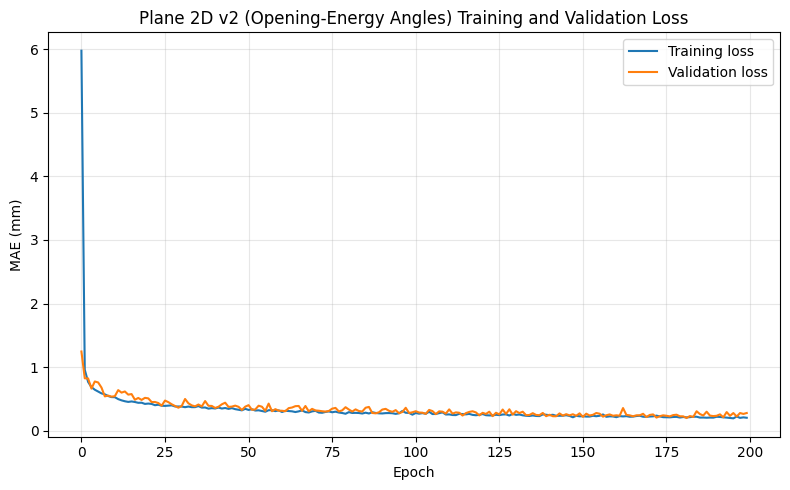

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_plane2dv2.history["loss"],
    label="Training loss"
)

plt.plot(
    history_plane2dv2.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("Plane 2D v2 (Opening-Energy Angles) Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.9.2 X, Y, Z MAE

In [74]:
from sklearn.metrics import r2_score
errors_plane2dv2 = (
    xyz_pred_plane2dv2 - y_test_plane2dv2
)

absolute_errors_plane2dv2 = np.abs(
    errors_plane2dv2
)

x_mae_plane2dv2 = np.mean(
    absolute_errors_plane2dv2[:, 0]
)

y_mae_plane2dv2 = np.mean(
    absolute_errors_plane2dv2[:, 1]
)

z_mae_plane2dv2 = np.mean(
    absolute_errors_plane2dv2[:, 2]
)

print("X MAE:", x_mae_plane2dv2, "mm")
print("Y MAE:", y_mae_plane2dv2, "mm")
print("Z MAE:", z_mae_plane2dv2, "mm")

X MAE: 0.21212380524993282 mm
Y MAE: 0.21109942564006642 mm
Z MAE: 0.20258806581919536 mm


### 4.9.3 True vs. predicted (per axis)

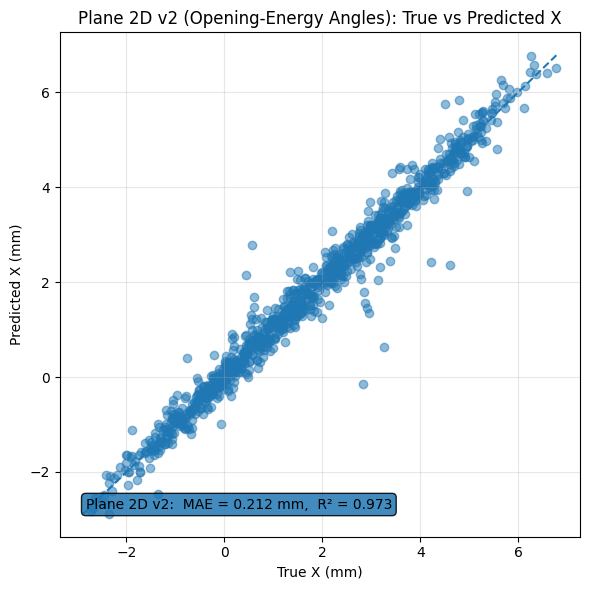

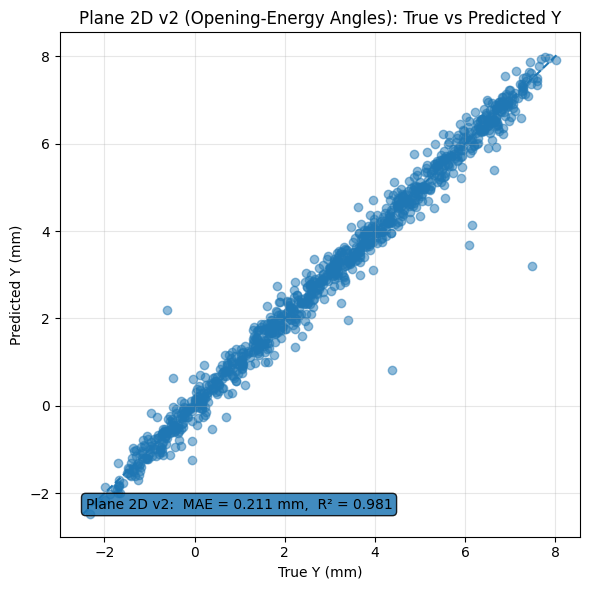

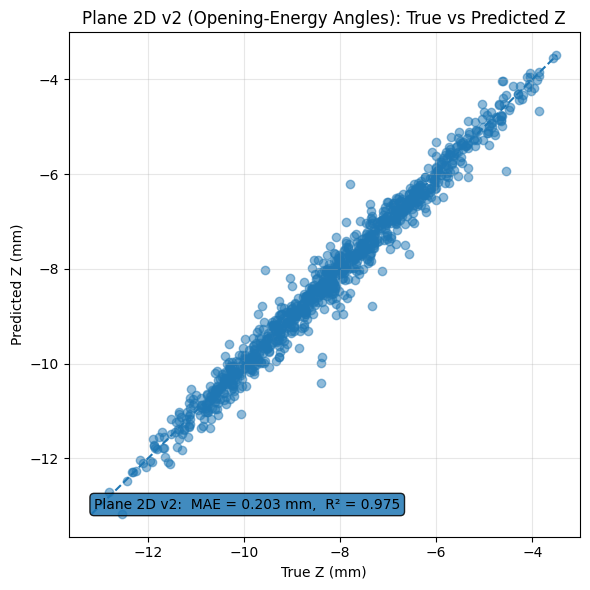

In [75]:
figures = [
    ("X", 0, x_mae_plane2dv2),
    ("Y", 1, y_mae_plane2dv2),
    ("Z", 2, z_mae_plane2dv2)
]

for coordinate, index, mae_val in figures:

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_plane2dv2[:, index],
        xyz_pred_plane2dv2[:, index],
        alpha=0.5
    )

    minimum = min(
        y_test_plane2dv2[:, index].min(),
        xyz_pred_plane2dv2[:, index].min()
    )

    maximum = max(
        y_test_plane2dv2[:, index].max(),
        xyz_pred_plane2dv2[:, index].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    r2_plane2dv2 = r2_score(
        y_test_plane2dv2[:, index],
        xyz_pred_plane2dv2[:, index]
    )

    metrics_text = (
        f"Plane 2D v2:  MAE = {mae_val:.3f} mm,  R² = {r2_plane2dv2:.3f}"
    )

    plt.text(
        0.05,
        0.05,
        metrics_text,
        transform=plt.gca().transAxes,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            alpha=0.85
        )
    )

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(
        f"Plane 2D v2 (Opening-Energy Angles): True vs Predicted {coordinate}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 4.9.4 3D reconstruction error

In [76]:
model_errors_plane2dv2 = np.linalg.norm(
    xyz_pred_plane2dv2 - y_test_plane2dv2,
    axis=1
)

mean_error_plane2dv2 = np.mean(
    model_errors_plane2dv2
)

median_error_plane2dv2 = np.median(
    model_errors_plane2dv2
)

std_error_plane2dv2 = np.std(
    model_errors_plane2dv2
)

max_error_plane2dv2 = np.max(
    model_errors_plane2dv2
)

print("2D PLANE MLP PERFORMANCE")

print(f"Mean 3D error   : {mean_error_plane2dv2:.3f} mm")
print(f"Median 3D error : {median_error_plane2dv2:.3f} mm")
print(f"Std 3D error    : {std_error_plane2dv2:.3f} mm")
print(f"Maximum error   : {max_error_plane2dv2:.3f} mm")

print()

print(f"X MAE           : {x_mae_plane2dv2:.3f} mm")
print(f"Y MAE           : {y_mae_plane2dv2:.3f} mm")
print(f"Z MAE           : {z_mae_plane2dv2:.3f} mm")

print()


print("PLANE CONSTRAINT")

plane_points = plane_test_plane2dv2[:, 0:3]
plane_normals = plane_test_plane2dv2[:, 3:6]

plane_distances_plane2dv2 = np.abs(
    np.sum(
        (xyz_pred_plane2dv2 - plane_points)
        * plane_normals,
        axis=1
    )
)

print(
    f"Mean plane distance   : "
    f"{np.mean(plane_distances_plane2dv2):.6f} mm"
)

print(
    f"Median plane distance : "
    f"{np.median(plane_distances_plane2dv2):.6f} mm"
)

print(
    f"Maximum plane distance: "
    f"{np.max(plane_distances_plane2dv2):.6f} mm"
)

2D PLANE MLP PERFORMANCE
Mean 3D error   : 0.418 mm
Median 3D error : 0.332 mm
Std 3D error    : 0.372 mm
Maximum error   : 4.667 mm

X MAE           : 0.212 mm
Y MAE           : 0.211 mm
Z MAE           : 0.203 mm

PLANE CONSTRAINT
Mean plane distance   : 0.000000 mm
Median plane distance : 0.000000 mm
Maximum plane distance: 0.000000 mm


### 4.9.5 Baseline comparison (naive mean-position predictor)

In [77]:
mean_position_plane2dv2 = np.mean(
    y_train_plane2dv2,
    axis=0
)

print(
    "Mean annihilation position (train):",
    mean_position_plane2dv2
)

mean_predictions_plane2dv2 = np.tile(
    mean_position_plane2dv2,
    (len(y_test_plane2dv2), 1)
)

mean_errors_plane2dv2 = np.linalg.norm(
    mean_predictions_plane2dv2 - y_test_plane2dv2,
    axis=1
)

baseline_mean_plane2dv2 = np.mean(
    mean_errors_plane2dv2
)

baseline_median_plane2dv2 = np.median(
    mean_errors_plane2dv2
)

print(
    "\nMean-position baseline — mean 3D error:",
    baseline_mean_plane2dv2,
    "mm"
)

print(
    "Mean-position baseline — median 3D error:",
    baseline_median_plane2dv2,
    "mm"
)

improvement_plane2dv2 = (
    (baseline_mean_plane2dv2 - mean_error_plane2dv2)
    / baseline_mean_plane2dv2
    * 100
)

print(
    f"\n2D plane MLP mean 3D error: "
    f"{mean_error_plane2dv2:.3f} mm"
)

print(
    f"Baseline mean 3D error: "
    f"{baseline_mean_plane2dv2:.3f} mm"
)

print(
    f"Improvement over baseline: "
    f"{improvement_plane2dv2:.1f}%"
)

Mean annihilation position (train): [ 1.82516059  3.00046503 -8.14236138]

Mean-position baseline — mean 3D error: 3.5481860379629215 mm
Mean-position baseline — median 3D error: 3.6685539241921443 mm

2D plane MLP mean 3D error: 0.418 mm
Baseline mean 3D error: 3.548 mm
Improvement over baseline: 88.2%


### 4.9.6 2D projections

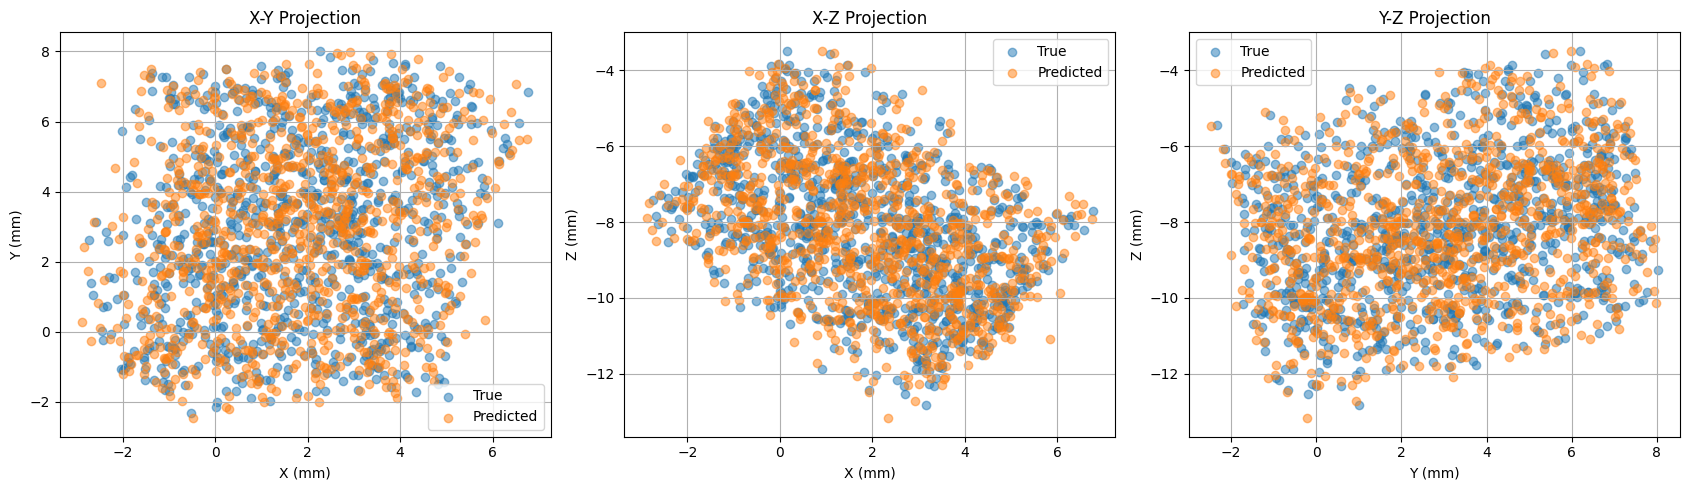

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
projections = [(0, 1, "X", "Y"), (0, 2, "X", "Z"), (1, 2, "Y", "Z")]

for ax, (i, j, xname, yname) in zip(axes, projections):
    ax.scatter(y_test_plane2dv2[:, i], y_test_plane2dv2[:, j], alpha=0.5, label="True")
    ax.scatter(xyz_pred_plane2dv2[:, i], xyz_pred_plane2dv2[:, j], alpha=0.5, label="Predicted")
    ax.set_xlabel(f"{xname} (mm)")
    ax.set_ylabel(f"{yname} (mm)")
    ax.set_title(f"{xname}-{yname} Projection")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### 4.9.7 Residuals

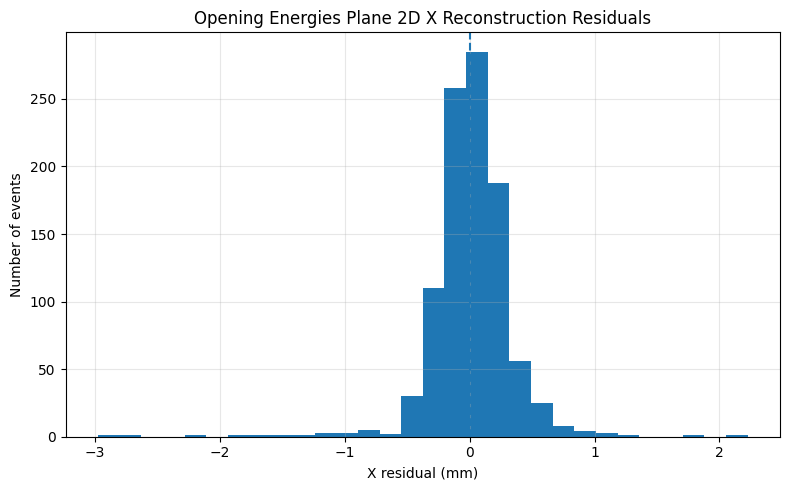

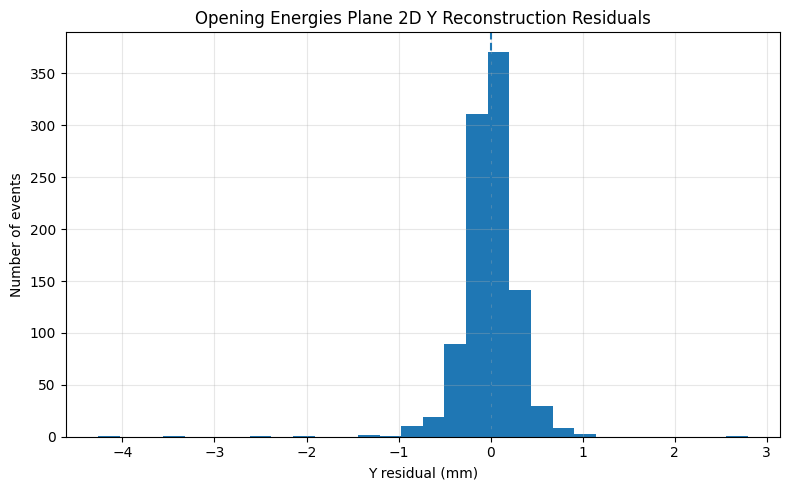

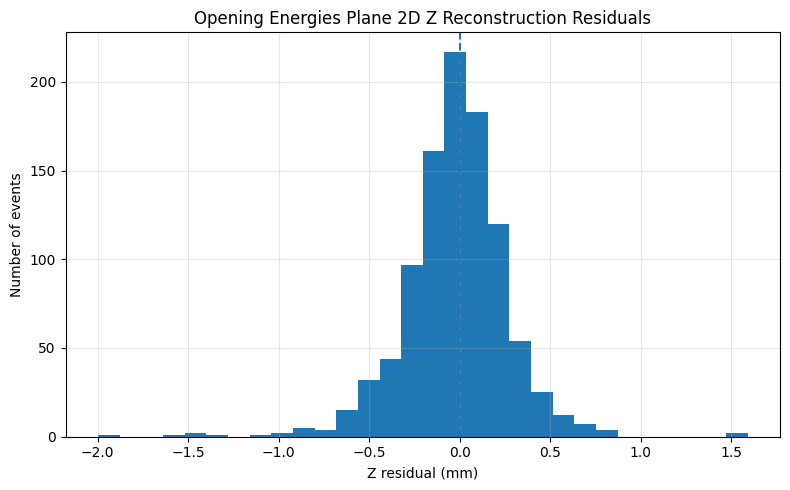

In [92]:
for coordinate, index in [
    ("X", 0),
    ("Y", 1),
    ("Z", 2)
]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        errors_plane2dv2[:, index],
        bins=30
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(f"{coordinate} residual (mm)")
    plt.ylabel("Number of events")
    plt.title(
        f"Opening Energies Plane 2D {coordinate} Reconstruction Residuals"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 4.9.8 Example reconstructed events

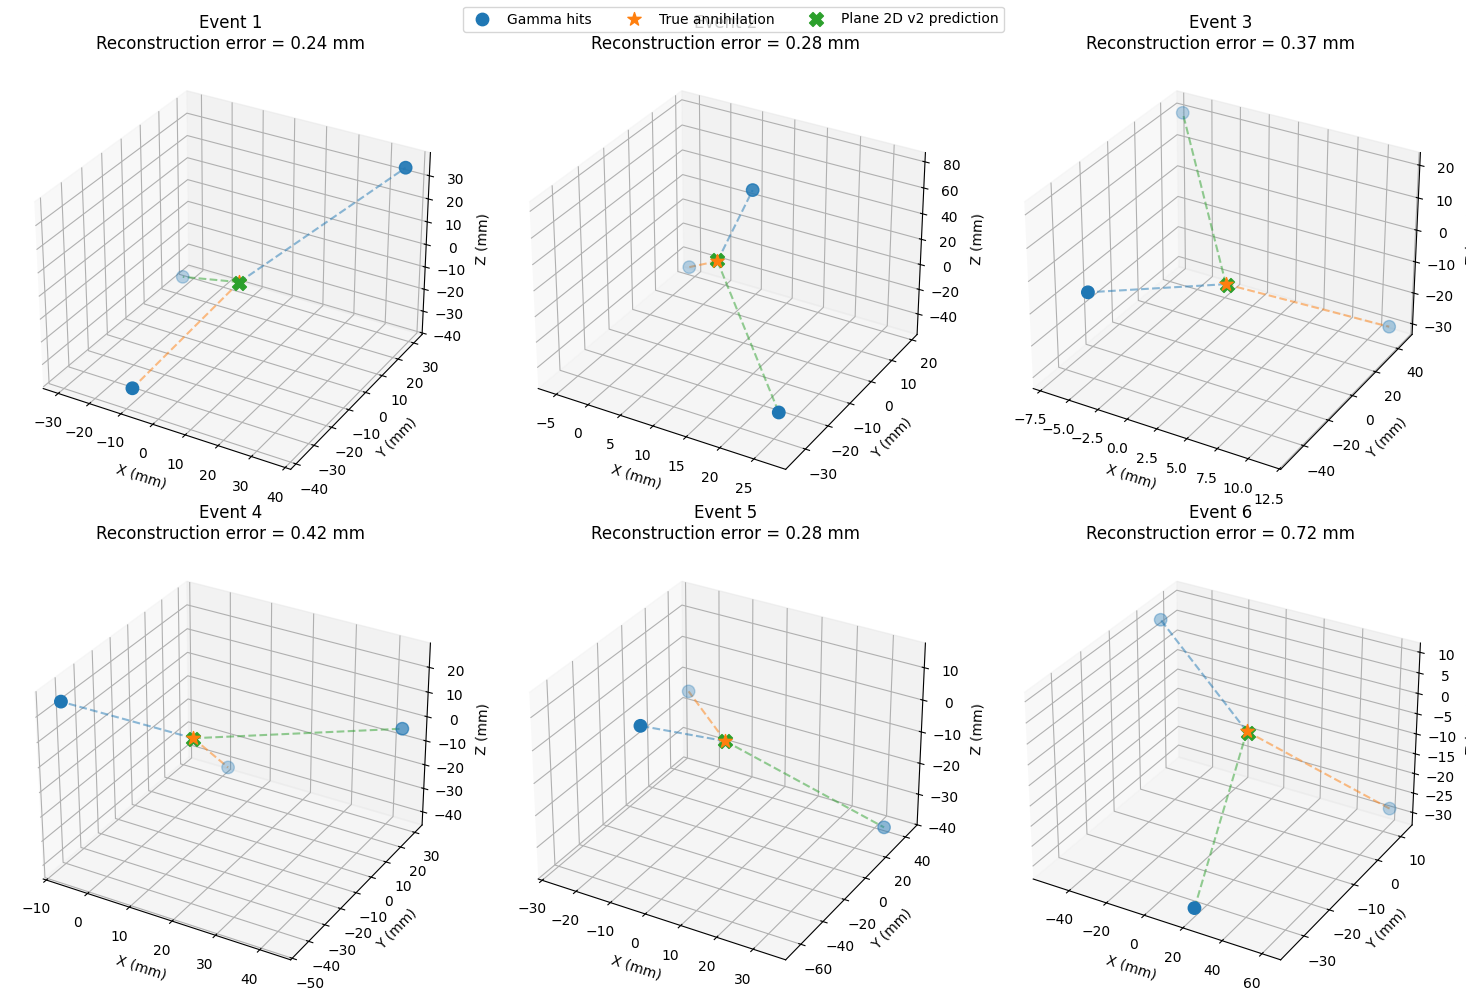

In [80]:
n_events = min(6, len(X_test_plane2dv2))

fig = plt.figure(figsize=(15, 10))

for i in range(n_events):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    # Use X_test_plane2dv2 for features
    hits = np.array([X_test_plane2dv2[i, 0:3], X_test_plane2dv2[i, 4:7], X_test_plane2dv2[i, 8:11]])
    # Use y_test_plane2dv2 for true positions
    true_pos = y_test_plane2dv2[i]
    # Use xyz_pred_plane2dv2 for predicted positions
    pred_pos = xyz_pred_plane2dv2[i]

    ax.scatter(hits[:, 0], hits[:, 1], hits[:, 2], s=80, marker="o", label="Gamma hits")
    ax.scatter(*true_pos, s=100, marker="*", label="True annihilation")
    ax.scatter(*pred_pos, s=100, marker="X", label="Plane 2D v2 prediction")

    for hit in hits:
        ax.plot([true_pos[0], hit[0]], [true_pos[1], hit[1]], [true_pos[2], hit[2]],
                linestyle="--", alpha=0.5)

    ax.plot([true_pos[0], pred_pos[0]], [true_pos[1], pred_pos[1]], [true_pos[2], pred_pos[2]],
            linestyle=":", linewidth=2)

    error = np.linalg.norm(pred_pos - true_pos)
    ax.set_title(f"Event {i+1}\nReconstruction error = {error:.2f} mm")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

### 4.10 Summary

In [101]:
overall_mae_plane2dv2 = np.mean(absolute_errors_plane2dv2)
r2_overall_plane2dv2 = r2_score(y_test_plane2dv2, xyz_pred_plane2dv2)

results_plane2dv2 = {
    "model": "opening energies plane 2d",
    "mae_x": x_mae_plane2dv2,
    "mae_y": y_mae_plane2dv2,
    "mae_z": z_mae_plane2dv2,
    "mae_overall": overall_mae_plane2dv2,
    "mean_3d_error_mm": mean_error_plane2dv2,
    "median_3d_error_mm": median_error_plane2dv2,
    "std_3d_error_mm": std_error_plane2dv2,
    "max_3d_error_mm": max_error_plane2dv2,
    "r2_overall": r2_overall_plane2dv2,
    "improvement_over_mean_baseline_pct": improvement_plane2dv2,
}

---
## 5. Comparing `mlp`, `pc_mlp`, `plane_2d`, and `plane_2d_v2`

### 5.1 Comparison table

In [104]:
comparison_rows = [
    {
        "Model": "mlp",
        "MAE X (mm)": results_mlp["mae_x"],
        "MAE Y (mm)": results_mlp["mae_y"],
        "MAE Z (mm)": results_mlp["mae_z"],
        "Overall MAE (mm)": results_mlp["mae_overall"],
        "Mean 3D error (mm)": results_mlp["mean_3d_error_mm"],
        "Median 3D error (mm)": results_mlp["median_3d_error_mm"],
        "STD 3D error (mm)": results_mlp["std_3d_error_mm"],
        "Max 3D error (mm)": results_mlp["max_3d_error_mm"],
        "R2": results_mlp["r2_overall"],

    },
    {
        "Model": "pc_mlp",
        "MAE X (mm)": results_pcmlp["mae_x"],
        "MAE Y (mm)": results_pcmlp["mae_y"],
        "MAE Z (mm)": results_pcmlp["mae_z"],
        "Overall MAE (mm)": results_pcmlp["mae_overall"],
        "Mean 3D error (mm)": results_pcmlp["mean_3d_error_mm"],
        "Median 3D error (mm)": results_pcmlp["median_3d_error_mm"],
        "STD 3D error (mm)": results_pcmlp["std_3d_error_mm"],
        "Max 3D error (mm)": results_pcmlp["max_3d_error_mm"],
        "R2": results_pcmlp["r2_overall"],
    },
    {
        "Model": "plane_2d",
        "MAE X (mm)": results_plane2d["mae_x"],
        "MAE Y (mm)": results_plane2d["mae_y"],
        "MAE Z (mm)": results_plane2d["mae_z"],
        "Overall MAE (mm)": results_plane2d["mae_overall"],
        "Mean 3D error (mm)": results_plane2d["mean_3d_error_mm"],
        "Median 3D error (mm)": results_plane2d["median_3d_error_mm"],
        "STD 3D error (mm)": results_plane2d["std_3d_error_mm"],
        "Max 3D error (mm)": results_plane2d["max_3d_error_mm"],
        "R2": results_plane2d["r2_overall"],
    },
    {
        "Model": "opening energies plane 2d",
        "MAE X (mm)": results_plane2dv2["mae_x"],
        "MAE Y (mm)": results_plane2dv2["mae_y"],
        "MAE Z (mm)": results_plane2dv2["mae_z"],
        "Overall MAE (mm)": results_plane2dv2["mae_overall"],
        "Mean 3D error (mm)": results_plane2dv2["mean_3d_error_mm"],
        "Median 3D error (mm)": results_plane2dv2["median_3d_error_mm"],
        "STD 3D error (mm)": results_plane2dv2["std_3d_error_mm"],
        "Max 3D error (mm)": results_plane2dv2["max_3d_error_mm"],
        "R2": results_plane2dv2["r2_overall"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df

,MAE X (mm),MAE Y (mm),MAE Z (mm),Overall MAE (mm),Mean 3D error (mm),Median 3D error (mm),STD 3D error (mm),Max 3D error (mm),R2
Model,,,,,,,,,
mlp,1.003586,0.945238,0.898263,0.949029,1.891012,1.688638,1.131136,13.358794,0.635121
pc_mlp,0.867529,0.960296,0.902584,0.910136,1.828645,1.610264,1.078514,7.077249,0.663761
plane_2d,0.686413,0.673420,0.695669,0.685167,1.370227,1.093819,1.092836,10.115775,0.763680
opening energies plane 2d,0.212124,0.211099,0.202588,0.208604,0.418129,0.332218,0.371549,4.667038,0.976765


###5.2 Plots for Comparison



1.   MAE (X,Y,Z, Overall)
2.   3D Errors
3.   R²




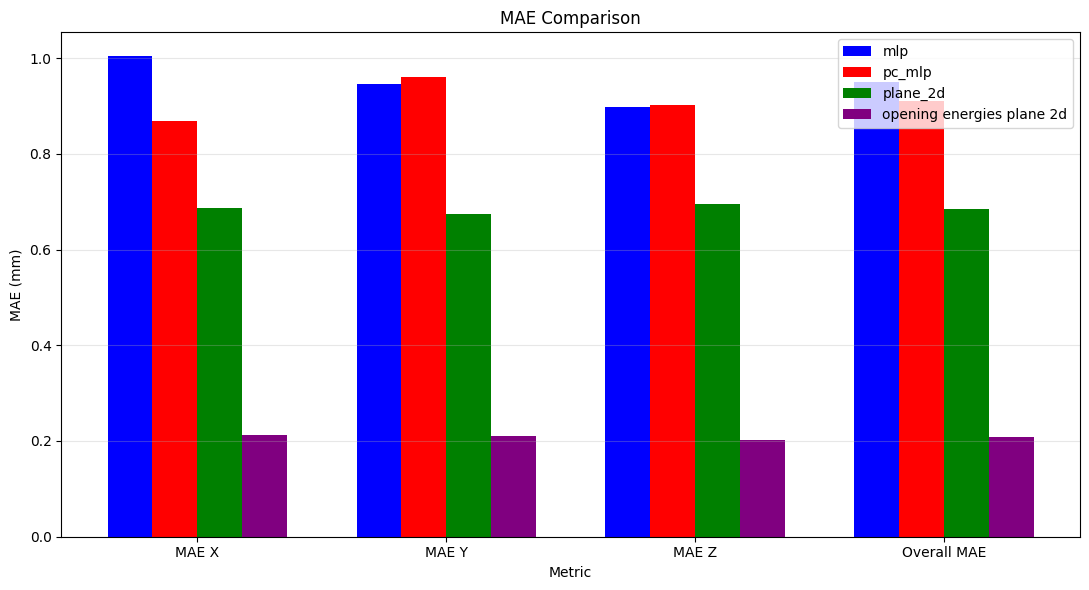

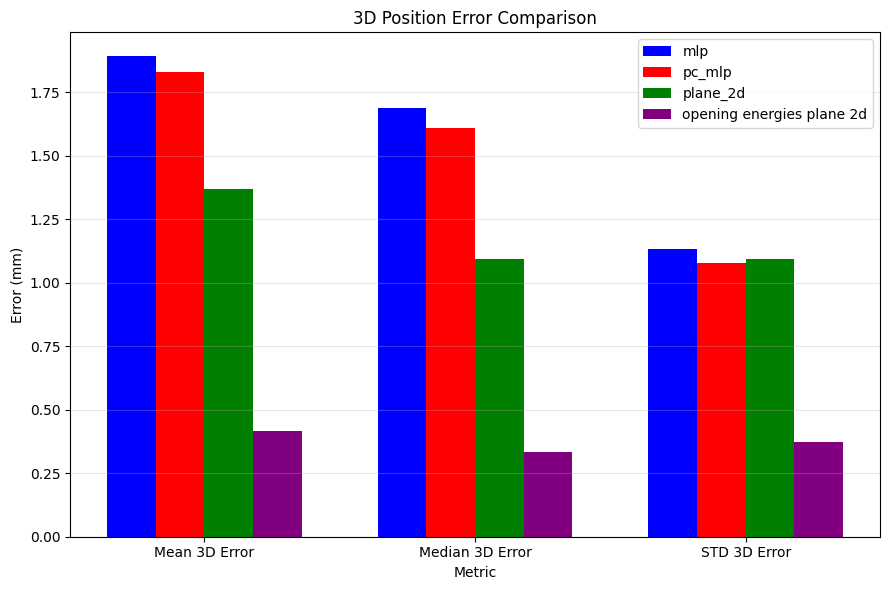

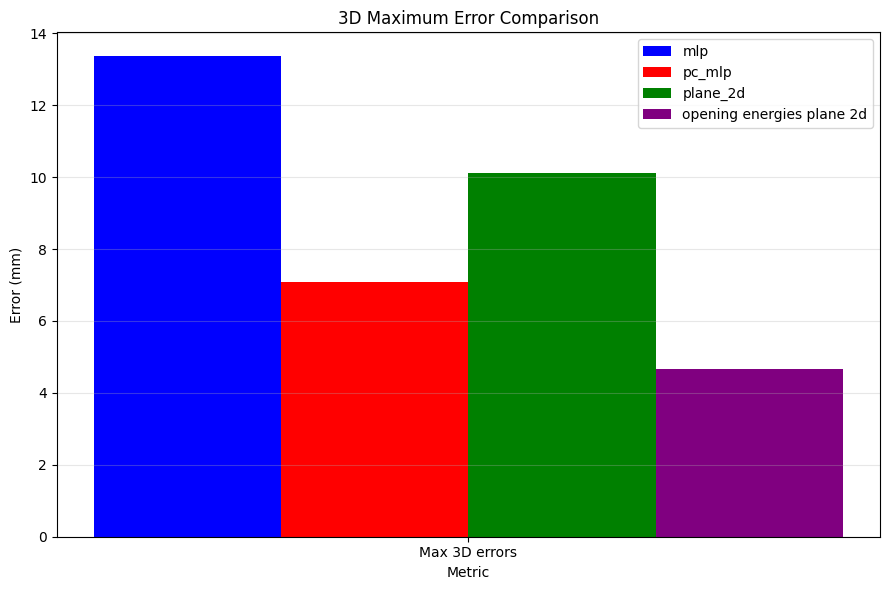

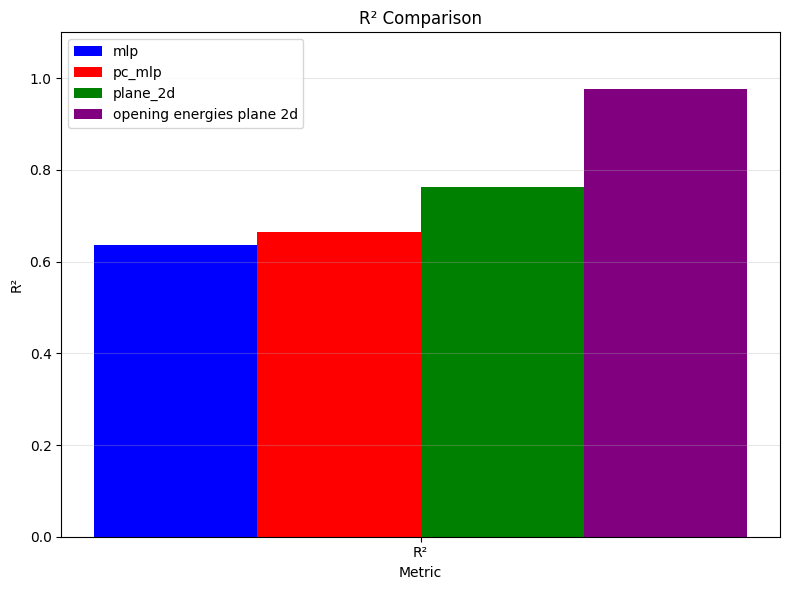

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# Model names and colours, driven by the comparison table itself
models = comparison_df.index.tolist()

colours = [
    "blue",
    "red",
    "green",
    "purple"
]

# Pull each metric straight from comparison_df, rather than retyping values
mae_x = comparison_df["MAE X (mm)"].tolist()
mae_y = comparison_df["MAE Y (mm)"].tolist()
mae_z = comparison_df["MAE Z (mm)"].tolist()
overall_mae = comparison_df["Overall MAE (mm)"].tolist()
mean_3d = comparison_df["Mean 3D error (mm)"].tolist()
median_3d = comparison_df["Median 3D error (mm)"].tolist()
std_3d = comparison_df["STD 3D error (mm)"].tolist()
max_3d = comparison_df["Max 3D error (mm)"].tolist()
r2 = comparison_df["R2"].tolist()



# Plot 1: MAE


metrics = [
    "MAE X",
    "MAE Y",
    "MAE Z",
    "Overall MAE"
]

mae_data = np.array([
    mae_x,
    mae_y,
    mae_z,
    overall_mae
])

x = np.arange(len(metrics))
width = 0.18

plt.figure(figsize=(11, 6))

for i, model in enumerate(models):

    plt.bar(
        x + (i - 1.5) * width,
        mae_data[:, i],
        width,
        label=model,
        color=colours[i]
    )

plt.xticks(x, metrics)
plt.ylabel("MAE (mm)")
plt.xlabel("Metric")
plt.title("MAE Comparison")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# Plot 2: 3D error by metric

#2.1
metrics_3d = [
    "Mean 3D Error",
    "Median 3D Error",
    "STD 3D Error"

]

error_data = np.array([
    mean_3d,
    median_3d,
    std_3d
])

x = np.arange(len(metrics_3d))
width = 0.18

plt.figure(figsize=(9, 6))

for i, model in enumerate(models):

    plt.bar(
        x + (i - 1.5) * width,
        error_data[:, i],
        width,
        label=model,
        color=colours[i]
    )

plt.xticks(x, metrics_3d)
plt.ylabel("Error (mm)")
plt.xlabel("Metric")
plt.title("3D Position Error Comparison")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

#2.2 just max

metrics_3d = [
    'Max 3D errors'

]

error_data = np.array([
    max_3d
])

x = np.arange(len(metrics_3d))
width = 0.18

plt.figure(figsize=(9, 6))

for i, model in enumerate(models):

    plt.bar(
        x + (i - 1.5) * width,
        error_data[:, i],
        width,
        label=model,
        color=colours[i]
    )

plt.xticks(x, metrics_3d)
plt.ylabel("Error (mm)")
plt.xlabel("Metric")
plt.title("3D Maximum Error Comparison")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Plot 3: R² comparison


plt.figure(figsize=(8, 6))

x = np.arange(1)
width = 0.18

for i, model in enumerate(models):

    plt.bar(
        x + (i - 1.5) * width,
        [r2[i]],
        width,
        label=model,
        color=colours[i]
    )

plt.xticks(x, ["R²"])
plt.ylabel("R²")
plt.xlabel("Metric")
plt.title("R² Comparison")
plt.ylim(0, 1.1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 5.4 Distribution of 3D reconstruction errors

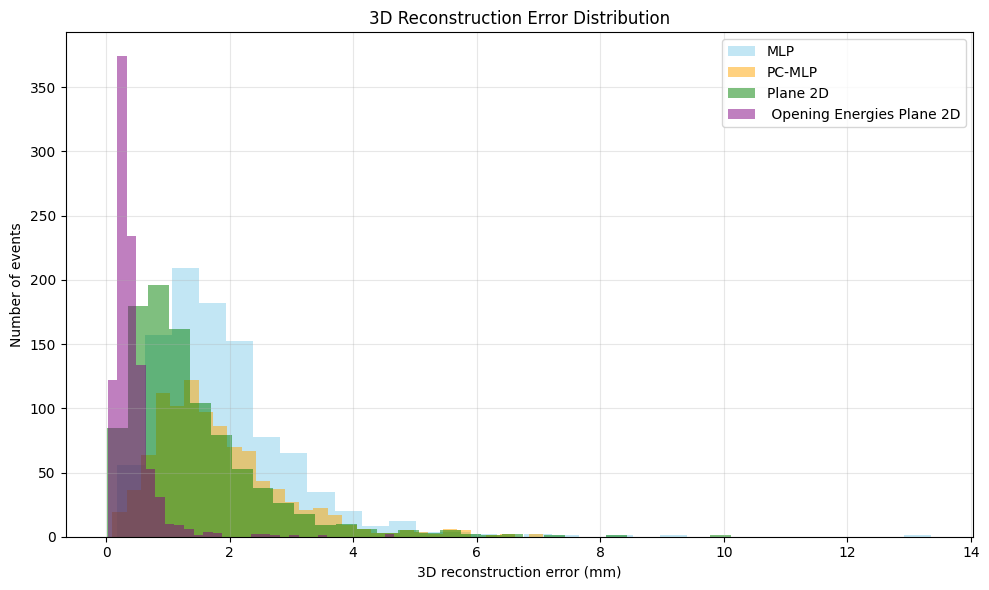

In [113]:
plt.figure(figsize=(10, 6))



plt.hist(errors_mlp, bins=30, alpha=0.5, label="MLP", color = 'skyblue')
plt.hist(reconstruction_error_pc_mlp, bins=30, alpha=0.5, label="PC-MLP", color='orange')
plt.hist(error_3d_plane2d, bins=30, alpha=0.5, label="Plane 2D", color='green')
plt.hist(model_errors_plane2dv2, bins=30, alpha=0.5, label=" Opening Energies Plane 2D", color='purple')

plt.xlabel("3D reconstruction error (mm)")
plt.ylabel("Number of events")
plt.title("3D Reconstruction Error Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 True vs. predicted, per axis, all four models

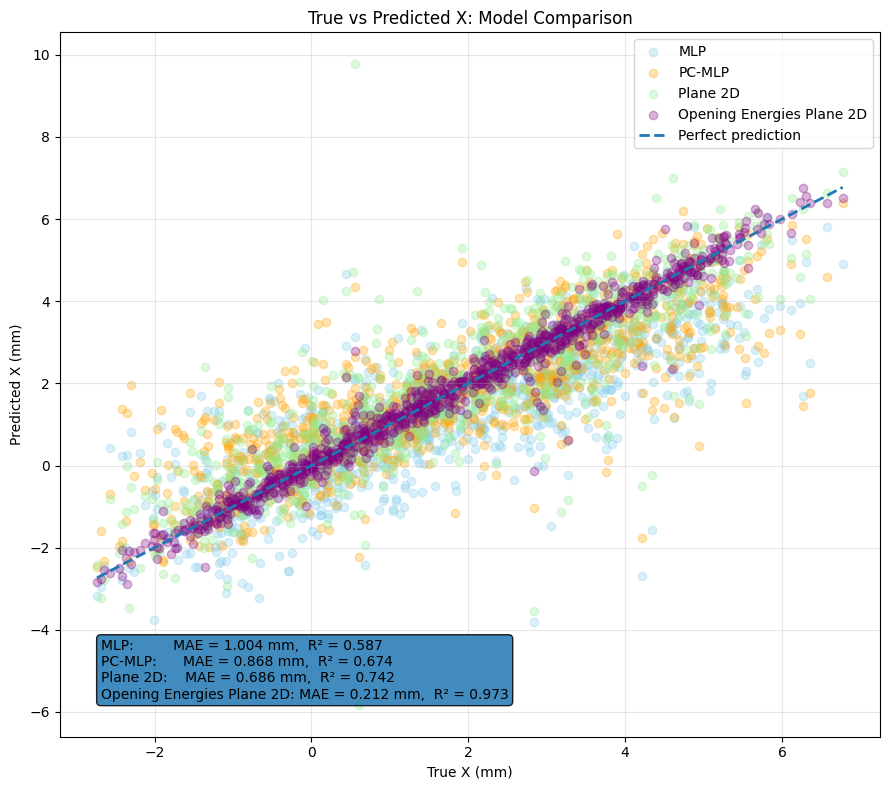

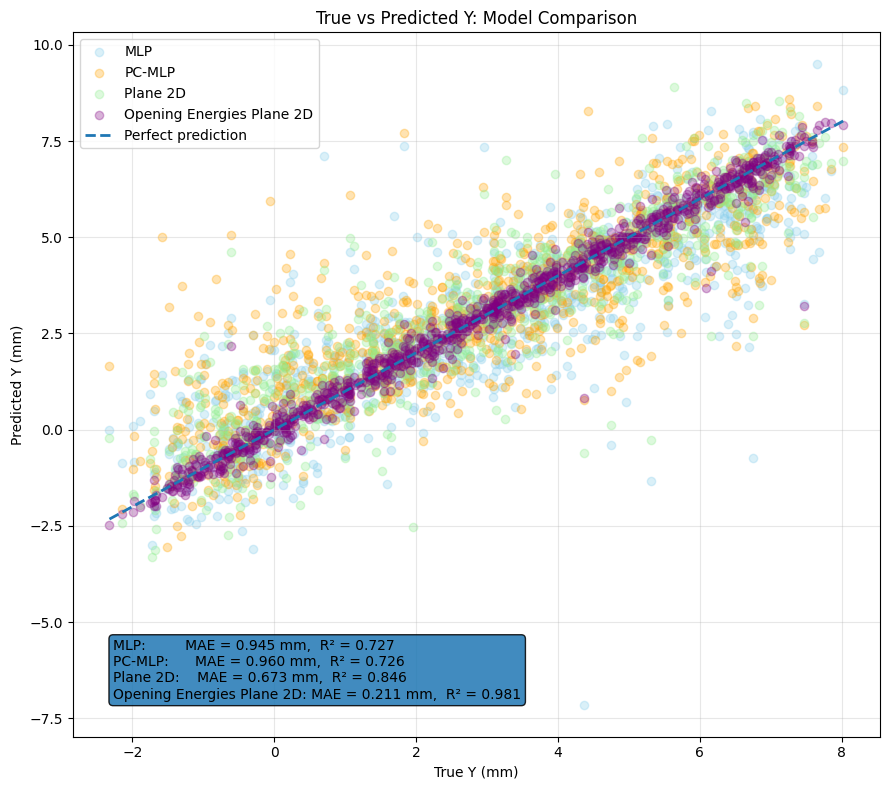

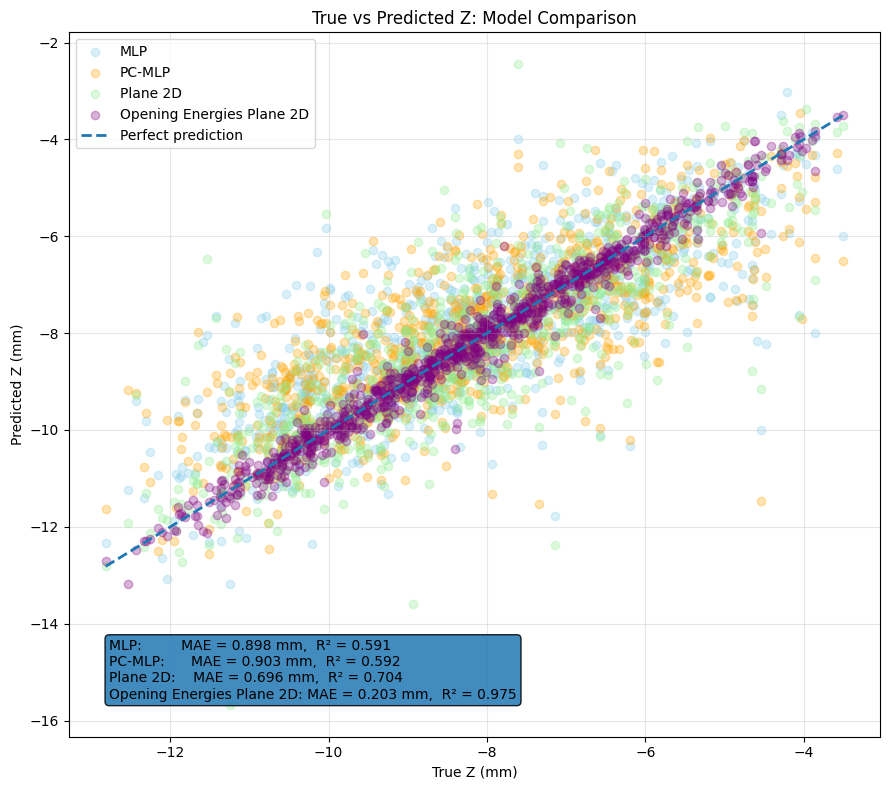

In [111]:
for coordinate, index in [("X", 0), ("Y", 1), ("Z", 2)]:

    plt.figure(figsize=(9, 8))

    true_mlp, pred_mlp = y_test_mlp[:, index], y_pred_mlp[:, index]
    true_pcmlp, pred_pcmlp = y_test_pcmlp[:, index], y_pred_pc_mlp[:, index]
    true_plane2d, pred_plane2d = y_test_plane2d[:, index], xyz_pred_plane2d[:, index]
    true_plane2dv2, pred_plane2dv2 = y_test_plane2dv2[:, index], xyz_pred_plane2dv2[:, index]

    # Define colors for each model
    colours = ["skyblue", "orange", "lightgreen", "purple"]

    plt.scatter(true_mlp, pred_mlp, alpha=0.3, label="MLP", color=colours[0])
    plt.scatter(true_pcmlp, pred_pcmlp, alpha=0.3, label="PC-MLP", color=colours[1])
    plt.scatter(true_plane2d, pred_plane2d, alpha=0.3, label="Plane 2D", color=colours[2])
    plt.scatter(true_plane2dv2, pred_plane2dv2, alpha=0.3, label="Opening Energies Plane 2D", color=colours[3])

    minimum = min(true_mlp.min(), true_pcmlp.min(), true_plane2d.min(), true_plane2dv2.min())
    maximum = max(true_mlp.max(), true_pcmlp.max(), true_plane2d.max(), true_plane2dv2.max())
    plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", linewidth=2, label="Perfect prediction")

    mae_mlp = np.mean(np.abs(pred_mlp - true_mlp))
    mae_pcmlp = np.mean(np.abs(pred_pcmlp - true_pcmlp))
    mae_plane2d = np.mean(np.abs(pred_plane2d - true_plane2d))
    mae_plane2dv2 = np.mean(np.abs(pred_plane2dv2 - true_plane2dv2))

    r2_mlp = r2_score(true_mlp, pred_mlp)
    r2_pcmlp = r2_score(true_pcmlp, pred_pcmlp)
    r2_plane2d = r2_score(true_plane2d, pred_plane2d)
    r2_plane2dv2 = r2_score(true_plane2dv2, pred_plane2dv2)

    metrics_text = (
        f"MLP:         MAE = {mae_mlp:.3f} mm,  R² = {r2_mlp:.3f}\n"
        f"PC-MLP:      MAE = {mae_pcmlp:.3f} mm,  R² = {r2_pcmlp:.3f}\n"
        f"Plane 2D:    MAE = {mae_plane2d:.3f} mm,  R² = {r2_plane2d:.3f}\n"
        f"Opening Energies Plane 2D: MAE = {mae_plane2dv2:.3f} mm,  R² = {r2_plane2dv2:.3f}"
    )

    plt.text(0.05, 0.05, metrics_text, transform=plt.gca().transAxes,
             verticalalignment="bottom", bbox=dict(boxstyle="round", alpha=0.85))

    plt.xlabel(f"True {coordinate} (mm)")
    plt.ylabel(f"Predicted {coordinate} (mm)")
    plt.title(f"True vs Predicted {coordinate}: Model Comparison")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

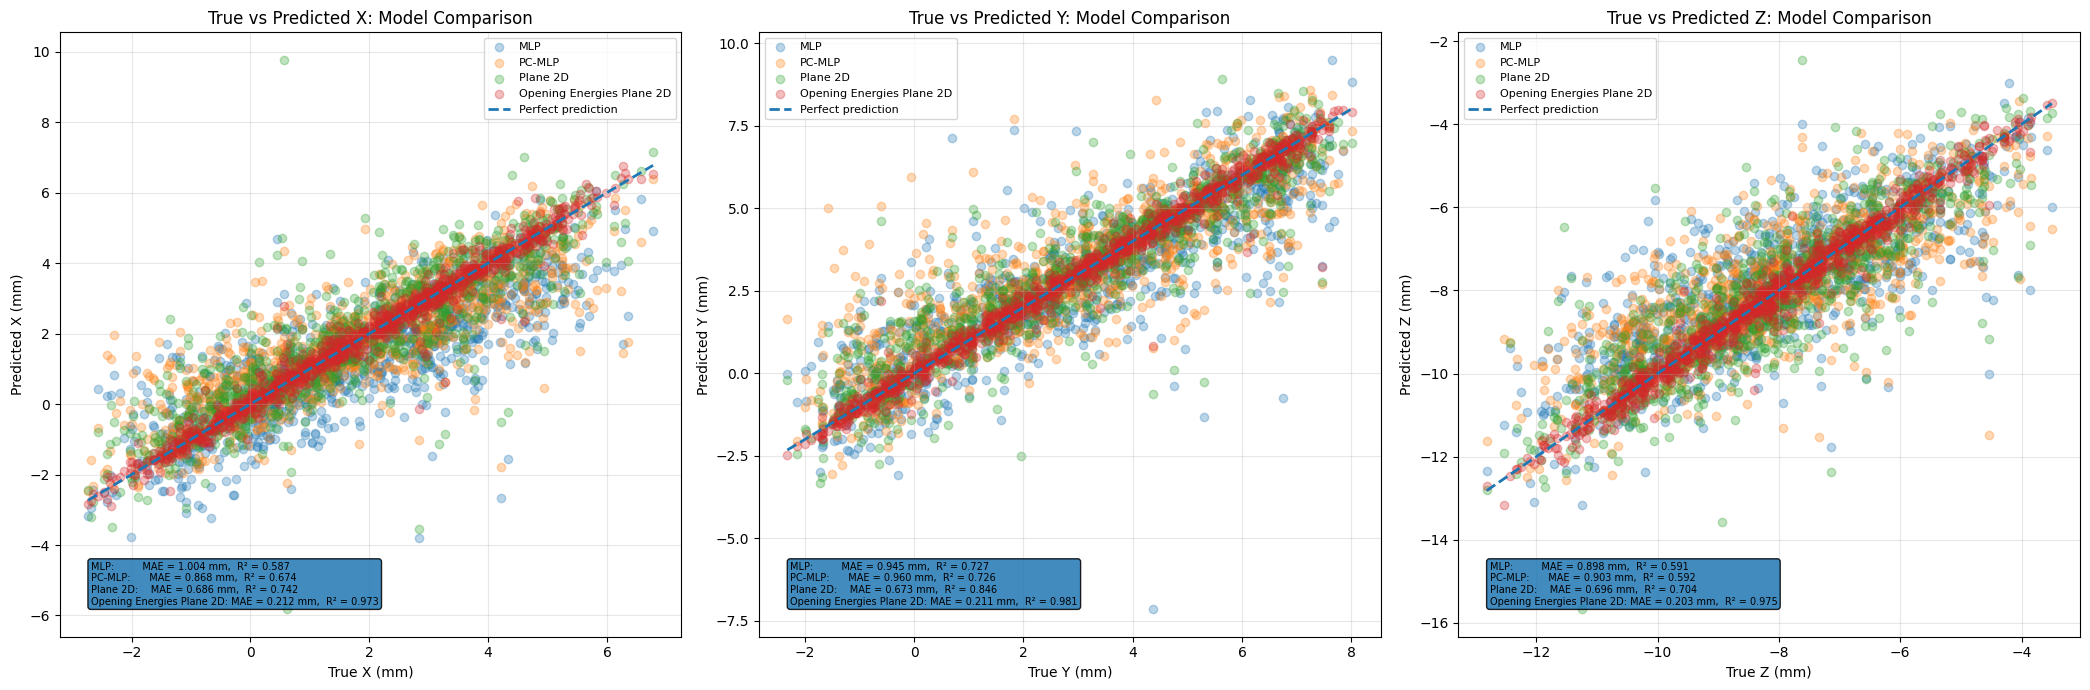

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (coordinate, index) in zip(axes, [("X", 0), ("Y", 1), ("Z", 2)]):

    true_mlp, pred_mlp = y_test_mlp[:, index], y_pred_mlp[:, index]
    true_pcmlp, pred_pcmlp = y_test_pcmlp[:, index], y_pred_pc_mlp[:, index]
    true_plane2d, pred_plane2d = y_test_plane2d[:, index], xyz_pred_plane2d[:, index]
    true_plane2dv2, pred_plane2dv2 = y_test_plane2dv2[:, index], xyz_pred_plane2dv2[:, index]

    ax.scatter(true_mlp, pred_mlp, alpha=0.3, label="MLP")
    ax.scatter(true_pcmlp, pred_pcmlp, alpha=0.3, label="PC-MLP")
    ax.scatter(true_plane2d, pred_plane2d, alpha=0.3, label="Plane 2D")
    ax.scatter(true_plane2dv2, pred_plane2dv2, alpha=0.3, label="Opening Energies Plane 2D")

    minimum = min(true_mlp.min(), true_pcmlp.min(), true_plane2d.min(), true_plane2dv2.min())
    maximum = max(true_mlp.max(), true_pcmlp.max(), true_plane2d.max(), true_plane2dv2.max())
    ax.plot([minimum, maximum], [minimum, maximum], linestyle="--", linewidth=2, label="Perfect prediction")

    mae_mlp = np.mean(np.abs(pred_mlp - true_mlp))
    mae_pcmlp = np.mean(np.abs(pred_pcmlp - true_pcmlp))
    mae_plane2d = np.mean(np.abs(pred_plane2d - true_plane2d))
    mae_plane2dv2 = np.mean(np.abs(pred_plane2dv2 - true_plane2dv2))

    r2_mlp = r2_score(true_mlp, pred_mlp)
    r2_pcmlp = r2_score(true_pcmlp, pred_pcmlp)
    r2_plane2d = r2_score(true_plane2d, pred_plane2d)
    r2_plane2dv2 = r2_score(true_plane2dv2, pred_plane2dv2)

    metrics_text = (
        f"MLP:         MAE = {mae_mlp:.3f} mm,  R² = {r2_mlp:.3f}\n"
        f"PC-MLP:      MAE = {mae_pcmlp:.3f} mm,  R² = {r2_pcmlp:.3f}\n"
        f"Plane 2D:    MAE = {mae_plane2d:.3f} mm,  R² = {r2_plane2d:.3f}\n"
        f"Opening Energies Plane 2D: MAE = {mae_plane2dv2:.3f} mm,  R² = {r2_plane2dv2:.3f}"
    )

    ax.text(0.05, 0.05, metrics_text, transform=ax.transAxes,
            verticalalignment="bottom", fontsize=7,
            bbox=dict(boxstyle="round", alpha=0.85))

    ax.set_xlabel(f"True {coordinate} (mm)")
    ax.set_ylabel(f"Predicted {coordinate} (mm)")
    ax.set_title(f"True vs Predicted {coordinate}: Model Comparison")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Distribution of errors — boxplot, all four models

In [ ]:
plt.figure(figsize=(9, 6))

plt.boxplot(
    [errors_mlp, reconstruction_error_pc_mlp, model_errors_plane2d, model_errors_plane2dv2],
    labels=["MLP", "PC-MLP", "Plane 2D", "Plane 2D v2"]
)

plt.ylabel("3D reconstruction error (mm)")
plt.title("Distribution of 3D Reconstruction Errors")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()